<a href="https://colab.research.google.com/github/GabrielThiel/ethereum-fraud-analysis/blob/main/notebooks/01-exploracao-datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Fraudes em Transações da Rede Ethereum

## Objetivo

Este notebook será utilizado para realizar a exploração, análise e preparação de datasets relacionados a transações da rede Ethereum, com foco na identificação de padrões associados a fraude, comportamento anômalo e endereços suspeitos.

## Etapas

1. Exploração inicial dos datasets
2. Análise da estrutura dos dados
3. Identificação de valores ausentes e inconsistentes
4. Limpeza e preparação dos dados
5. Análise das características (features)
6. Estudo das relações entre as features
7. Seleção das features relevantes
8. Visualização dos dados
9. Avaliação da possibilidade de integração entre datasets
10. Preparação do dataset final para modelos de aprendizado de máquina

## Bibliotecas

- Pandas
- Polars
- Matplotlib
- Scikit-learn

## Observação

As decisões de limpeza, seleção de features e integração dos datasets serão documentadas ao longo do projeto.

In [14]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import sklearn

print("Pandas:", pd.__version__)
print("Polars:", pl.__version__)
print("Scikit-learn:", sklearn.__version__)

Pandas: 2.2.3
Polars: 1.35.2
Scikit-learn: 1.6.1


In [15]:
import os

os.listdir("/content")

['.config', 'archive.zip', 'etfd', 'sample_data']

In [16]:
os.listdir("/content")

['.config', 'archive.zip', 'etfd', 'sample_data']

In [17]:
import zipfile

zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    print("Arquivos dentro do ZIP:")
    for arquivo in zip_ref.namelist():
        print(arquivo)

Arquivos dentro do ZIP:
ETFD_Dataset.txt


In [18]:
import zipfile
import os

zip_path = "/content/archive.zip"
extract_path = "/content/etfd"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['ETFD_Dataset.txt']


In [19]:
arquivo = "/content/etfd/ETFD_Dataset.txt"

with open(arquivo, "r", encoding="utf-8") as f:
    for i in range(10):
        print(repr(f.readline()))

'blockNumber\tconfirmations\tMonth\tDay\tHour\tmean_value_received\tvariance_value_received\ttotal_received\ttime_diff_first_last_received\ttotal_tx_sent\ttotal_tx_sent_malicious\ttotal_tx_sent_unique\ttotal_tx_sent_malicious_unique\ttotal_tx_received_malicious_unique\tFraud\n'
'19664511\t201879\t4\t16\t0\t0.1751904075\t0.0519971092909851\t0.7007616300000001\t246.45916666666668\t43.0\t0.0\t6.0\t0.0\t0.0\t0\n'
'16217669\t3648727\t12\t19\t8\t0.0842392024381043\t0.0344684110324226\t13.394033187658586\t625.4894328703704\t62.0\t0.0\t1.0\t0.0\t0.0\t0\n'
'14351953\t5514270\t3\t9\t10\t3.896735904391325\t101.819167885204\t467.608308526959\t1884.80613425926\t552.0\t0.0\t251.0\t0.0\t0.0\t0\n'
'19753020\t113094\t4\t28\t9\t0.1355401416682591\t0.0043894645704178\t1.4909415583508507\t225.1555555555556\t59.0\t0.0\t33.0\t0.0\t0.0\t0\n'
'19076055\t790248\t1\t24\t10\t0.2357174086643617\t0.1490361968081223\t43.372003194242566\t937.6813773148148\t423.0\t0.0\t97.0\t0.0\t0.0\t0\n'
'11530191\t8336003\t12\t26\

In [20]:
df_etfd = pd.read_csv(
    "/content/etfd/ETFD_Dataset.txt",
    sep="\t"
)

print("Dimensões:", df_etfd.shape)
print("\nColunas:")
print(df_etfd.columns.tolist())

Dimensões: (85003, 15)

Colunas:
['blockNumber', 'confirmations', 'Month', 'Day', 'Hour', 'mean_value_received', 'variance_value_received', 'total_received', 'time_diff_first_last_received', 'total_tx_sent', 'total_tx_sent_malicious', 'total_tx_sent_unique', 'total_tx_sent_malicious_unique', 'total_tx_received_malicious_unique', 'Fraud']


In [21]:
print("Distribuição da variável Fraud:")
print(df_etfd["Fraud"].value_counts())

print("\nValores nulos:")
print(df_etfd.isnull().sum())

print("\nDuplicatas:")
print(df_etfd.duplicated().sum())

print("\nTipos das colunas:")
print(df_etfd.dtypes)

Distribuição da variável Fraud:
Fraud
1    42504
0    42499
Name: count, dtype: int64

Valores nulos:
blockNumber                           0
confirmations                         0
Month                                 0
Day                                   0
Hour                                  0
mean_value_received                   0
variance_value_received               0
total_received                        0
time_diff_first_last_received         0
total_tx_sent                         0
total_tx_sent_malicious               0
total_tx_sent_unique                  0
total_tx_sent_malicious_unique        0
total_tx_received_malicious_unique    0
Fraud                                 0
dtype: int64

Duplicatas:
1533

Tipos das colunas:
blockNumber                             int64
confirmations                           int64
Month                                   int64
Day                                     int64
Hour                                    int64
mean_value_receiv

In [22]:
duplicados = df_etfd[df_etfd.duplicated(keep=False)]

print("Total de registros envolvidos em duplicatas:", len(duplicados))

print("\nQuantidade de grupos duplicados:")
print(
    duplicados
    .value_counts()
    .head(10)
)

Total de registros envolvidos em duplicatas: 2347

Quantidade de grupos duplicados:
blockNumber  confirmations  Month  Day  Hour  mean_value_received  variance_value_received  total_received  time_diff_first_last_received  total_tx_sent  total_tx_sent_malicious  total_tx_sent_unique  total_tx_sent_malicious_unique  total_tx_received_malicious_unique  Fraud
18612163     1253932        11     20   9     0.0                  0.0                      0.0             0.0                            1.0            0.0                      1.0                   0.0                             0.0                                 0        26
4080765      15686565       7      27   12    0.0                  0.0                      0.0             0.0                            1.0            1.0                      1.0                   1.0                             0.0                                 1        26
4080766      15686564       7      27   12    0.0                  0.0         

In [23]:
print(duplicados.head(10))

     blockNumber  confirmations  Month  Day  Hour  mean_value_received  \
27      19594020         272335      4    6     3             0.000000   
30      19478485         387634      3   20    21             0.000000   
104     13938512        5927764      1    4    10             0.000000   
232     17739992        2126519      7   21     7             0.000000   
453     19485142         381392      3   21    19             0.000000   
508     17683402        2183109      7   13     8             1.818397   
672     13535674        6330820     11    2     5             1.364448   
821     18849083        1017449     12   23    14             0.000000   
848     19494658         371782      3   23     3             0.000000   
976     15522645        4343624      9   12    19             0.084252   

     variance_value_received  total_received  time_diff_first_last_received  \
27                  0.000000        0.000000                       0.000000   
30                  0.00000

In [24]:
# Verifica se existem registros com as mesmas features,
# mas com classificações Fraud diferentes.

features = [col for col in df_etfd.columns if col != "Fraud"]

conflitos = (
    df_etfd
    .groupby(features)["Fraud"]
    .nunique()
)

conflitos = conflitos[conflitos > 1]

print("Quantidade de grupos com conflito de classificação:", len(conflitos))

Quantidade de grupos com conflito de classificação: 0


In [25]:
if len(conflitos) > 0:
    print("\nExemplos de conflitos:")
    print(conflitos.head(10))
else:
    print("\nNenhum conflito encontrado.")


Nenhum conflito encontrado.


In [26]:
df_etfd_sem_duplicatas = df_etfd.drop_duplicates()

print("Registros antes:", len(df_etfd))
print("Registros depois:", len(df_etfd_sem_duplicatas))
print("Registros removidos:", len(df_etfd) - len(df_etfd_sem_duplicatas))

print("\nDistribuição das classes após remoção:")
print(df_etfd_sem_duplicatas["Fraud"].value_counts())

Registros antes: 85003
Registros depois: 83470
Registros removidos: 1533

Distribuição das classes após remoção:
Fraud
0    42200
1    41270
Name: count, dtype: int64


## Análise e tratamento de duplicatas

Na análise inicial do dataset ETFD foram identificados 1.533 registros
duplicados.

Antes de realizar a remoção, foi verificado se existiam registros com
as mesmas características (features), mas associados a classes diferentes
na variável `Fraud`.

Não foram encontrados conflitos de classificação.

Dessa forma, os registros duplicados foram considerados redundantes para
a análise e a remoção foi considerada apropriada.

### Resultado

- Registros originais: 85.003
- Registros duplicados removidos: 1.533
- Registros após a remoção: 83.470
- `Fraud = 0`: 42.200
- `Fraud = 1`: 41.270

A distribuição das classes permaneceu aproximadamente equilibrada após
a remoção das duplicatas.

In [27]:
df_etfd_sem_duplicatas.describe().T

,count,mean,std,min,25%,50%,75%,max
blockNumber,83470.0,1.146481e+07,5.822563e+06,1311219.0,5747731.75,11738664.0,1.729350e+07,1.986646e+07
confirmations,83470.0,8.352634e+06,5.779062e+06,6.0,2572708.75,8098807.0,1.402083e+07,1.855500e+07
Month,83470.0,6.023613e+00,3.251159e+00,1.0,3.00,6.0,9.000000e+00,1.200000e+01
Day,83470.0,1.577437e+01,8.686819e+00,1.0,8.00,16.0,2.300000e+01,3.100000e+01
Hour,83470.0,1.218169e+01,6.607071e+00,0.0,7.00,13.0,1.800000e+01,2.300000e+01
mean_value_received,83470.0,4.679450e+00,3.189324e+01,0.0,0.00,0.0,4.941925e-01,7.501000e+02
variance_value_received,83470.0,4.140936e+03,3.478089e+04,0.0,0.00,0.0,4.074424e-01,1.124700e+06
total_received,83470.0,4.045047e+03,3.257804e+04,0.0,0.00,0.0,2.467630e+01,2.817010e+05
time_diff_first_last_received,83470.0,3.095189e+02,5.221020e+02,0.0,0.00,0.0,5.070435e+02,2.986429e+03
total_tx_sent,83470.0,6.544432e+02,1.760126e+03,1.0,2.00,26.0,4.630000e+02,9.996000e+03


In [28]:
# Verificar valores negativos
print("Valores negativos por coluna:")
print((df_etfd_sem_duplicatas < 0).sum())

# Verificar quantidade e percentual de zeros
print("\nValores iguais a zero:")

zeros = (df_etfd_sem_duplicatas == 0).sum()
percentual_zeros = (zeros / len(df_etfd_sem_duplicatas) * 100).round(2)

resultado_zeros = pd.DataFrame({
    "quantidade": zeros,
    "percentual": percentual_zeros
})

print(resultado_zeros)

Valores negativos por coluna:
blockNumber                           0
confirmations                         0
Month                                 0
Day                                   0
Hour                                  0
mean_value_received                   0
variance_value_received               0
total_received                        0
time_diff_first_last_received         0
total_tx_sent                         0
total_tx_sent_malicious               0
total_tx_sent_unique                  0
total_tx_sent_malicious_unique        0
total_tx_received_malicious_unique    0
Fraud                                 0
dtype: int64

Valores iguais a zero:
                                    quantidade  percentual
blockNumber                                  0        0.00
confirmations                                0        0.00
Month                                        0        0.00
Day                                          0        0.00
Hour                                  

## Análise de valores negativos e zeros

Foi realizada uma análise para identificar valores negativos e valores
iguais a zero nas variáveis do dataset ETFD.

Não foram encontrados valores negativos em nenhuma das variáveis.

Foi observada, entretanto, uma elevada concentração de valores iguais a
zero em algumas características. A variável `total_tx_received_malicious_unique`
apresentou 94,62% de valores iguais a zero, enquanto outras variáveis
relacionadas a transações maliciosas apresentaram aproximadamente 56,20%
de valores iguais a zero.

Os valores zero não foram considerados automaticamente como dados
incorretos, pois podem representar situações válidas no contexto das
transações da rede Ethereum. Dessa forma, nenhuma variável foi removida
nesta etapa com base apenas na quantidade de zeros.

In [29]:
print("Quantidade de valores únicos por coluna:\n")

valores_unicos = df_etfd_sem_duplicatas.nunique().sort_values()

print(valores_unicos)

Quantidade de valores únicos por coluna:

Fraud                                     2
total_tx_received_malicious_unique        8
Month                                    12
Hour                                     24
Day                                      31
total_tx_sent_malicious_unique           47
total_tx_sent_malicious                  57
total_tx_sent_unique                    179
total_tx_sent                           397
variance_value_received                4932
time_diff_first_last_received          5028
total_received                         5720
mean_value_received                    5766
blockNumber                           81766
confirmations                         82104
dtype: int64


In [30]:
print("\nFeatures com apenas um valor:")

features_constantes = valores_unicos[valores_unicos == 1]

print(features_constantes)


Features com apenas um valor:
Series([], dtype: int64)


## Análise de variabilidade das features

Foi analisada a quantidade de valores únicos presentes em cada coluna
para identificar possíveis características constantes.

Nenhuma das variáveis apresentou apenas um valor distinto. Portanto,
não foram identificadas features constantes que pudessem ser removidas
com base exclusivamente na ausência de variabilidade.

A variável `total_tx_received_malicious_unique` apresentou apenas 8
valores distintos, porém essa característica não foi removida nesta
etapa, pois uma baixa quantidade de valores distintos não implica,
isoladamente, ausência de poder preditivo.

In [31]:
correlacao = df_etfd_sem_duplicatas.corr()

correlacao

,blockNumber,confirmations,Month,Day,Hour,mean_value_received,variance_value_received,total_received,time_diff_first_last_received,total_tx_sent,total_tx_sent_malicious,total_tx_sent_unique,total_tx_sent_malicious_unique,total_tx_received_malicious_unique,Fraud
blockNumber,1.000000,-0.999992,-0.085223,0.025180,-0.043880,0.098894,0.096273,0.103397,0.307038,0.192195,-0.083367,0.176091,-0.221154,-0.133065,-0.881178
confirmations,-0.999992,1.000000,0.085103,-0.025234,0.043623,-0.098574,-0.096003,-0.103133,-0.306151,-0.191331,0.082096,-0.175672,0.220992,0.132924,0.879261
Month,-0.085223,0.085103,1.000000,-0.022942,0.022558,-0.016267,-0.018381,-0.019837,0.021282,-0.063808,-0.009771,-0.016603,-0.082779,-0.042158,0.088868
Day,0.025180,-0.025234,-0.022942,1.000000,0.006138,-0.009050,-0.007223,-0.002872,0.010170,0.000158,0.008160,0.040744,0.011617,0.012509,-0.015846
Hour,-0.043880,0.043623,0.022558,0.006138,1.000000,-0.048113,-0.046711,-0.050613,-0.025438,-0.036403,0.031824,-0.005585,-0.003729,-0.003624,0.068609
mean_value_received,0.098894,-0.098574,-0.016267,-0.009050,-0.048113,1.000000,0.976424,0.896267,0.160738,0.443311,-0.029604,-0.035510,-0.027321,-0.005747,-0.124132
variance_value_received,0.096273,-0.096003,-0.018381,-0.007223,-0.046711,0.976424,1.000000,0.912015,0.136472,0.457579,-0.027352,-0.041931,-0.027859,-0.016528,-0.115878
total_received,0.103397,-0.103133,-0.019837,-0.002872,-0.050613,0.896267,0.912015,1.000000,0.148397,0.528380,-0.028280,-0.033616,-0.028584,-0.016330,-0.121480
time_diff_first_last_received,0.307038,-0.306151,0.021282,0.010170,-0.025438,0.160738,0.136472,0.148397,1.000000,0.088077,-0.064456,0.096096,-0.014509,0.162602,-0.374177
total_tx_sent,0.192195,-0.191331,-0.063808,0.000158,-0.036403,0.443311,0.457579,0.528380,0.088077,1.000000,0.055377,0.462169,0.000821,0.001894,-0.269745


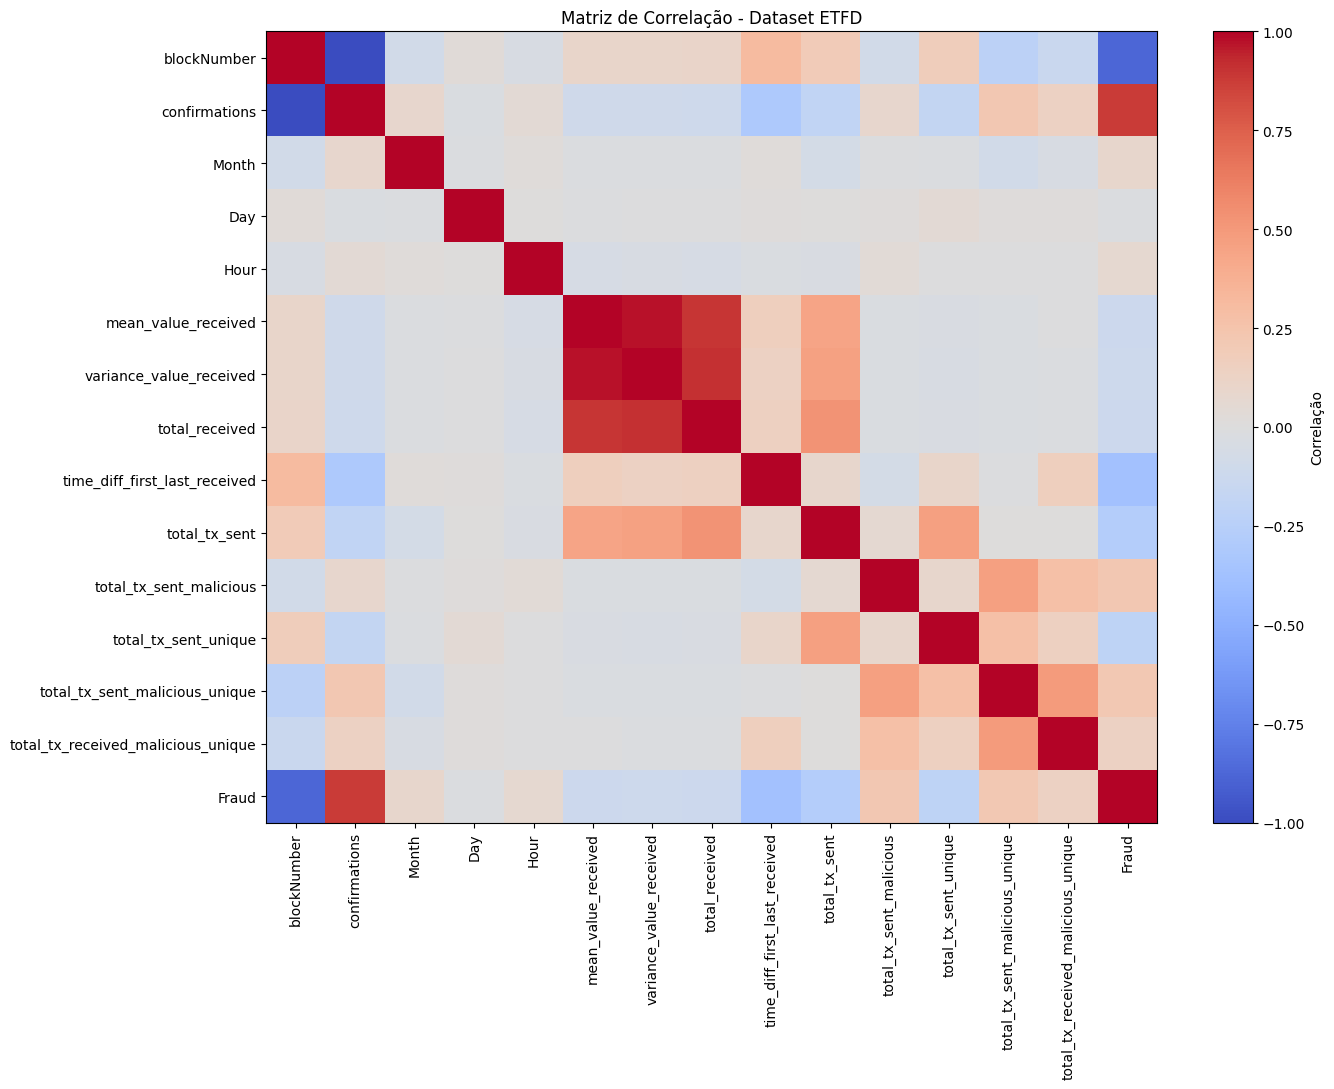

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 11))

plt.imshow(correlacao, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)

plt.colorbar(label="Correlação")

plt.xticks(
    range(len(correlacao.columns)),
    correlacao.columns,
    rotation=90
)

plt.yticks(
    range(len(correlacao.index)),
    correlacao.index
)

plt.title("Matriz de Correlação - Dataset ETFD")

plt.tight_layout()
plt.show()

## Análise de correlação

Foi calculada a matriz de correlação entre as variáveis numéricas do
dataset ETFD e posteriormente gerado um heatmap utilizando Matplotlib.

Foi identificada uma correlação extremamente forte e negativa entre
`blockNumber` e `confirmations` (aproximadamente -0,999992), indicando
que essas variáveis possuem comportamento altamente relacionado.

Também foram observadas correlações elevadas entre `mean_value_received`,
`variance_value_received` e `total_received`.

Em relação à variável-alvo `Fraud`, as maiores correlações foram
observadas com `blockNumber` (-0,881178) e `confirmations` (0,879261).

Esses resultados não foram utilizados isoladamente para remover
variáveis. As features com alta correlação serão investigadas
posteriormente considerando seu significado, possível redundância e
eventual risco de vazamento de informação (data leakage).

In [33]:
# Relação entre blockNumber e confirmations

df_etfd_sem_duplicatas["block_confirmations_sum"] = (
    df_etfd_sem_duplicatas["blockNumber"] +
    df_etfd_sem_duplicatas["confirmations"]
)

df_etfd_sem_duplicatas["block_confirmations_diff"] = (
    df_etfd_sem_duplicatas["blockNumber"] -
    df_etfd_sem_duplicatas["confirmations"]
)

print("Estatísticas da soma:")
print(df_etfd_sem_duplicatas["block_confirmations_sum"].describe())

print("\nEstatísticas da diferença:")
print(df_etfd_sem_duplicatas["block_confirmations_diff"].describe())

Estatísticas da soma:
count    8.347000e+04
mean     1.981744e+07
std      4.941146e+04
min      1.976733e+07
25%      1.976745e+07
50%      1.986606e+07
75%      1.986630e+07
max      1.986653e+07
Name: block_confirmations_sum, dtype: float64

Estatísticas da diferença:
count    8.347000e+04
mean     3.112172e+06
std      1.160160e+07
min     -1.724379e+07
25%     -8.273614e+06
50%      3.636778e+06
75%      1.472090e+07
max      1.986640e+07
Name: block_confirmations_diff, dtype: float64


/tmp/ipykernel_1483/1694632101.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_etfd_sem_duplicatas["block_confirmations_sum"] = (
/tmp/ipykernel_1483/1694632101.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_etfd_sem_duplicatas["block_confirmations_diff"] = (


In [34]:
df_etfd_sem_duplicatas[
    ["blockNumber", "confirmations"]
].head(20)

,blockNumber,confirmations
0,19664511,201879
1,16217669,3648727
2,14351953,5514270
3,19753020,113094
4,19076055,790248
5,11530191,8336003
6,18817741,1048774
7,18637845,1228302
8,19068121,797945
9,12189510,7676543


In [35]:
from sklearn.linear_model import LinearRegression

X = df_etfd_sem_duplicatas[["blockNumber"]]
y = df_etfd_sem_duplicatas["confirmations"]

modelo_relacao = LinearRegression()
modelo_relacao.fit(X, y)

print("Coeficiente:", modelo_relacao.coef_[0])
print("Intercepto:", modelo_relacao.intercept_)
print("R²:", modelo_relacao.score(X, y))

Coeficiente: -0.9925206602742654
Intercepto: 19731691.4445638
R²: 0.9999836819498155


In [36]:
df_etfd_sem_duplicatas = df_etfd_sem_duplicatas.drop(
    columns=["block_confirmations_sum", "block_confirmations_diff"],
    errors="ignore"
).copy()

In [37]:
relacao_blocos = (
    df_etfd_sem_duplicatas["blockNumber"] +
    df_etfd_sem_duplicatas["confirmations"]
)

print("Quantidade de valores diferentes:", relacao_blocos.nunique())

print("\nEstatísticas:")
print(relacao_blocos.describe())

print("\nMenores valores:")
print(relacao_blocos.nsmallest(10).tolist())

print("\nMaiores valores:")
print(relacao_blocos.nlargest(10).tolist())

Quantidade de valores diferentes: 633

Estatísticas:
count    8.347000e+04
mean     1.981744e+07
std      4.941146e+04
min      1.976733e+07
25%      1.976745e+07
50%      1.986606e+07
75%      1.986630e+07
max      1.986653e+07
dtype: float64

Menores valores:
[19767328, 19767328, 19767328, 19767328, 19767328, 19767328, 19767328, 19767328, 19767328, 19767328]

Maiores valores:
[19866534, 19866534, 19866534, 19866534, 19866534, 19866534, 19866534, 19866534, 19866534, 19866534]


## Investigação da relação entre `blockNumber` e `confirmations`

Para investigar a forte correlação observada entre `blockNumber` e
`confirmations`, foi calculada a soma das duas variáveis.

A soma apresentou 633 valores distintos, variando de 19.767.328 a
19.866.534 blocos. A existência de diferentes valores de referência
indica que `confirmations` não parece ter sido calculado em relação a
uma única altura de bloco para todo o dataset.

Os resultados são compatíveis com uma relação aproximada entre as
variáveis na forma:

`confirmations ≈ altura_do_bloco_de_referência - blockNumber`

Essa relação explica a correlação extremamente forte e negativa
observada anteriormente.

A relação será investigada adicionalmente antes de qualquer decisão
sobre remoção de uma das variáveis, especialmente devido à possibilidade
de redundância e de vazamento de informação (data leakage).

In [38]:
analise_temporal = (
    df_etfd_sem_duplicatas
    .groupby("blockNumber")["Fraud"]
    .agg(["count", "mean"])
)

analise_temporal["percentual_fraude"] = (
    analise_temporal["mean"] * 100
)

print(analise_temporal.describe())

              count          mean  percentual_fraude
count  81766.000000  81766.000000       81766.000000
mean       1.020840      0.488830          48.882991
std        0.163003      0.499802          49.980215
min        1.000000      0.000000           0.000000
25%        1.000000      0.000000           0.000000
50%        1.000000      0.000000           0.000000
75%        1.000000      1.000000         100.000000
max        9.000000      1.000000         100.000000


In [39]:
# Dividir blockNumber em 20 faixas de tamanho semelhante

df_temporal = df_etfd_sem_duplicatas.copy()

df_temporal["faixa_bloco"] = pd.qcut(
    df_temporal["blockNumber"],
    q=20,
    duplicates="drop"
)

analise_faixas = (
    df_temporal
    .groupby("faixa_bloco", observed=True)["Fraud"]
    .agg(
        quantidade="count",
        quantidade_fraude="sum",
        percentual_fraude="mean"
    )
)

analise_faixas["percentual_fraude"] *= 100

analise_faixas

,quantidade,quantidade_fraude,percentual_fraude
faixa_bloco,,,
"(1311218.999, 4536241.4]",4174,4015,96.190704
"(4536241.4, 5030448.4]",4173,3740,89.623772
"(5030448.4, 5289304.45]",4174,3713,88.955438
"(5289304.45, 5510854.4]",4173,4038,96.764917
"(5510854.4, 5747731.75]",4174,4123,98.778150
"(5747731.75, 5998690.1]",4173,4088,97.963096
"(5998690.1, 6306548.3]",4174,4130,98.945855
"(6306548.3, 6365519.4]",4173,4170,99.928109
"(6365519.4, 7406806.55]",4174,4052,97.077144


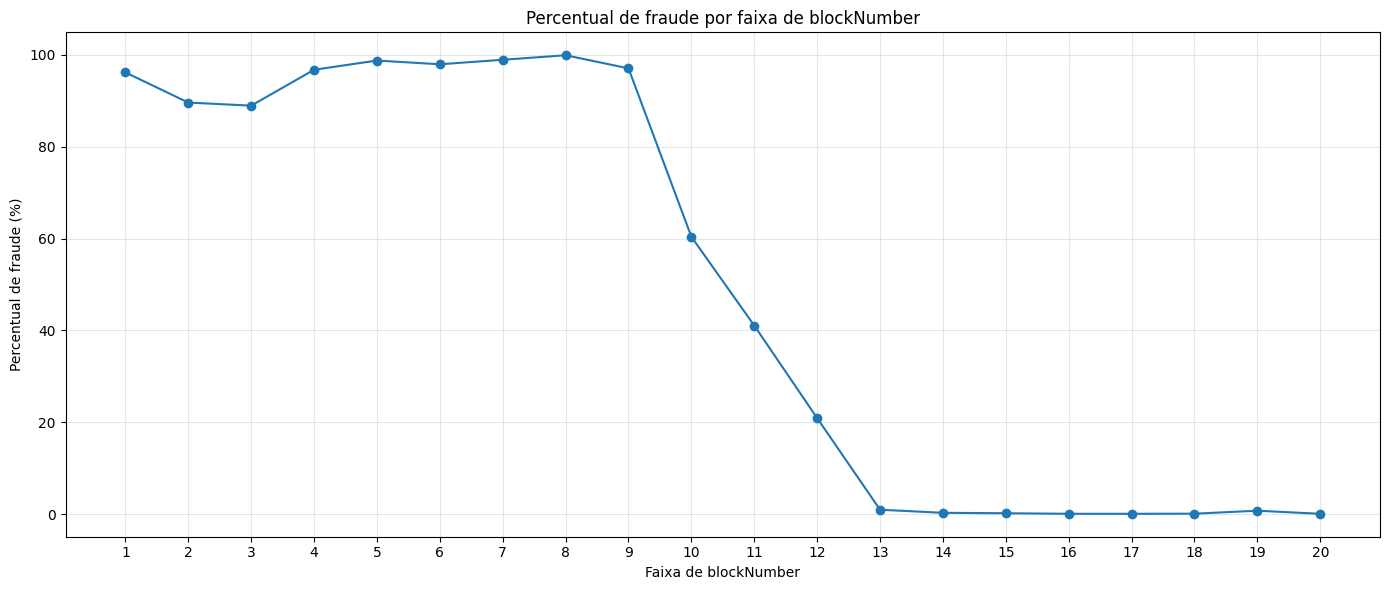

In [40]:
plt.figure(figsize=(14, 6))

plt.plot(
    range(1, len(analise_faixas) + 1),
    analise_faixas["percentual_fraude"],
    marker="o"
)

plt.xlabel("Faixa de blockNumber")
plt.ylabel("Percentual de fraude (%)")
plt.title("Percentual de fraude por faixa de blockNumber")
plt.xticks(range(1, len(analise_faixas) + 1))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Análise temporal da variável `Fraud`

Para investigar a forte correlação observada entre `blockNumber` e a
variável-alvo `Fraud`, os registros foram divididos em 20 faixas de
`blockNumber` com quantidades aproximadamente iguais de observações.

Foi observada uma forte variação da proporção de transações fraudulentas
ao longo das faixas. Nas primeiras faixas, a proporção de fraude ficou
próxima de 90% a 100%, enquanto nas faixas posteriores caiu para valores
próximos de 0%.

Esse comportamento indica uma forte dependência temporal entre
`blockNumber` e a variável `Fraud`.

O resultado exige investigação adicional da origem e do processo de
rotulagem do dataset antes da seleção definitiva das features e da
construção dos modelos de classificação.

Essa análise também levanta a possibilidade de dependência temporal ou
vazamento de informação, caso a variável `blockNumber` permita ao modelo
inferir a classe principalmente a partir do período em que a observação
foi registrada.

## Investigação de possível vazamento de informação

A documentação e o código-fonte do ETDG foram analisados para compreender
a origem das variáveis utilizadas no ETFD.

Foi identificado que algumas características, como
`total_tx_sent_malicious`, `total_tx_sent_malicious_unique` e
`total_tx_received_malicious_unique`, são calculadas utilizando uma lista
de endereços classificados previamente como maliciosos.

Essa mesma lista é utilizada no processo de definição da variável-alvo
`Fraud`.

Dessa forma, existe a possibilidade de vazamento de informação entre as
features e o alvo. Essa hipótese será testada empiricamente antes da
seleção definitiva das características.

Também foi identificado que as características nodais são calculadas
sobre o conjunto completo de transações, o que pode introduzir
informações posteriores ao momento da transação quando utilizadas em uma
previsão temporal.

In [41]:
features_maliciosas = [
    "total_tx_sent_malicious",
    "total_tx_sent_malicious_unique",
    "total_tx_received_malicious_unique"
]

analise_maliciosas = (
    df_etfd_sem_duplicatas
    .groupby("Fraud")[features_maliciosas]
    .agg(["mean", "median", "min", "max"])
)

analise_maliciosas

total_tx_sent_malicious                      \
                         mean median  min     max   
Fraud                                               
0                    2.292393    0.0  0.0   720.0   
1                   98.380422    1.0  0.0  1464.0   

      total_tx_sent_malicious_unique                     \
                                mean median  min    max   
Fraud                                                     
0                           1.229668    0.0  0.0  293.0   
1                          23.441677    1.0  0.0  293.0   

      total_tx_received_malicious_unique                    
                                    mean median  min   max  
Fraud                                                       
0                               0.015853    0.0  0.0  13.0  
1                               0.355876    0.0  0.0  13.0

In [42]:
for feature in features_maliciosas:
    print(f"\n=== {feature} ===")

    tabela = pd.crosstab(
        df_etfd_sem_duplicatas["Fraud"],
        df_etfd_sem_duplicatas[feature] > 0,
        normalize="index"
    ) * 100

    print(tabela)


=== total_tx_sent_malicious ===
total_tx_sent_malicious      False      True 
Fraud                                        
0                        95.277251   4.722749
1                        16.251514  83.748486

=== total_tx_sent_malicious_unique ===
total_tx_sent_malicious_unique      False      True 
Fraud                                               
0                               95.277251   4.722749
1                               16.251514  83.748486

=== total_tx_received_malicious_unique ===
total_tx_received_malicious_unique      False      True 
Fraud                                                   
0                                   99.296209   0.703791
1                                   89.842501  10.157499


In [43]:
print(df_etfd_sem_duplicatas.columns.tolist())

['blockNumber', 'confirmations', 'Month', 'Day', 'Hour', 'mean_value_received', 'variance_value_received', 'total_received', 'time_diff_first_last_received', 'total_tx_sent', 'total_tx_sent_malicious', 'total_tx_sent_unique', 'total_tx_sent_malicious_unique', 'total_tx_received_malicious_unique', 'Fraud']


In [44]:
# Correlação de cada feature com Fraud
correlacao_fraud = (
    df_etfd_sem_duplicatas
    .corr()["Fraud"]
    .drop("Fraud")
    .sort_values(key=abs, ascending=False)
)

print("Correlação das features com Fraud:")
print(correlacao_fraud)

Correlação das features com Fraud:
blockNumber                          -0.881178
confirmations                         0.879261
time_diff_first_last_received        -0.374177
total_tx_sent                        -0.269745
total_tx_sent_malicious               0.222328
total_tx_sent_malicious_unique        0.213733
total_tx_sent_unique                 -0.203807
total_tx_received_malicious_unique    0.133600
mean_value_received                  -0.124132
total_received                       -0.121480
variance_value_received              -0.115878
Month                                 0.088868
Hour                                  0.068609
Day                                  -0.015846
Name: Fraud, dtype: float64


In [45]:
# Correlação absoluta
print("\nCorrelação absoluta com Fraud:")
print(correlacao_fraud.abs().sort_values(ascending=False))


Correlação absoluta com Fraud:
blockNumber                           0.881178
confirmations                         0.879261
time_diff_first_last_received         0.374177
total_tx_sent                         0.269745
total_tx_sent_malicious               0.222328
total_tx_sent_malicious_unique        0.213733
total_tx_sent_unique                  0.203807
total_tx_received_malicious_unique    0.133600
mean_value_received                   0.124132
total_received                        0.121480
variance_value_received               0.115878
Month                                 0.088868
Hour                                  0.068609
Day                                   0.015846
Name: Fraud, dtype: float64


In [46]:
comparacao_fraud = (
    df_etfd_sem_duplicatas
    .groupby("Fraud")
    .mean(numeric_only=True)
    .T
)

comparacao_fraud["diferenca_absoluta"] = (
    comparacao_fraud[1] - comparacao_fraud[0]
).abs()

comparacao_fraud.sort_values(
    "diferenca_absoluta",
    ascending=False
)

Fraud,0,1,diferenca_absoluta
blockNumber,1.653864e+07,6.276634e+06,1.026201e+07
confirmations,3.327661e+06,1.349084e+07,1.016318e+07
variance_value_received,8.126581e+03,6.547654e+01,8.061105e+03
total_received,7.958743e+03,4.315810e+01,7.915585e+03
total_tx_sent,1.123965e+03,1.743407e+02,9.496246e+02
time_diff_first_last_received,5.027118e+02,1.119725e+02,3.907393e+02
total_tx_sent_malicious,2.292393e+00,9.838042e+01,9.608803e+01
total_tx_sent_unique,1.153578e+02,3.544580e+01,7.991200e+01
total_tx_sent_malicious_unique,1.229668e+00,2.344168e+01,2.221201e+01
mean_value_received,8.594545e+00,6.761295e-01,7.918415e+00


## Análise da relação entre features e a variável-alvo

Foi analisada a correlação entre cada característica e a variável-alvo
`Fraud`, utilizando o coeficiente de correlação de Pearson.

As maiores correlações em valor absoluto foram observadas em
`blockNumber` (-0,881178) e `confirmations` (0,879261), seguidas por
`time_diff_first_last_received` (-0,374177) e `total_tx_sent`
(-0,269745).

As características relacionadas a endereços maliciosos apresentaram
correlações positivas com `Fraud`, porém de menor magnitude.

Também foram comparadas as médias das características entre as classes
`Fraud = 0` e `Fraud = 1`. Essa comparação mostrou diferenças expressivas
em algumas variáveis, mas as diferenças de média não foram utilizadas
isoladamente como critério de seleção, pois variáveis com distribuições
assimétricas e valores extremos podem apresentar médias muito diferentes
sem necessariamente possuírem alto poder discriminativo.

Os resultados foram utilizados para identificar características que
merecem investigação adicional antes da seleção definitiva das features.

In [47]:
from sklearn.metrics import roc_auc_score

features = [
    col for col in df_etfd_sem_duplicatas.columns
    if col != "Fraud"
]

resultados_auc = []

for feature in features:
    auc = roc_auc_score(
        df_etfd_sem_duplicatas["Fraud"],
        df_etfd_sem_duplicatas[feature]
    )

    # AUC abaixo de 0.5 pode ser invertida
    auc_ajustada = max(auc, 1 - auc)

    resultados_auc.append({
        "feature": feature,
        "auc": auc,
        "auc_ajustada": auc_ajustada
    })

auc_features = (
    pd.DataFrame(resultados_auc)
    .sort_values("auc_ajustada", ascending=False)
)

auc_features

,feature,auc,auc_ajustada
0,blockNumber,0.032481,0.967519
1,confirmations,0.966261,0.966261
10,total_tx_sent_malicious,0.896753,0.896753
12,total_tx_sent_malicious_unique,0.892559,0.892559
9,total_tx_sent,0.241566,0.758434
8,time_diff_first_last_received,0.263552,0.736448
7,total_received,0.287149,0.712851
11,total_tx_sent_unique,0.296065,0.703935
5,mean_value_received,0.296411,0.703589
6,variance_value_received,0.310924,0.689076


## Análise do poder discriminativo individual das features

Foi calculada a área sob a curva ROC (ROC-AUC) individualmente para cada
feature, utilizando a variável `Fraud` como alvo.

As maiores AUCs ajustadas foram observadas em `blockNumber` (0,967519) e
`confirmations` (0,966261), indicando que essas variáveis, isoladamente,
apresentam elevada capacidade de separar as classes.

Também foram observadas AUCs elevadas para `total_tx_sent_malicious`
(0,896753) e `total_tx_sent_malicious_unique` (0,892559).

Esses resultados reforçam as observações realizadas anteriormente sobre
a forte dependência temporal do dataset e sobre a relação das features
relacionadas a endereços maliciosos com a variável-alvo.

A AUC individual foi utilizada nesta etapa como análise exploratória e
não como avaliação definitiva de um modelo preditivo, pois os valores
foram calculados sobre a própria base utilizada na análise.

Nenhuma feature foi removida nesta etapa. Os resultados serão utilizados
posteriormente para comparar diferentes conjuntos de features e avaliar
o impacto das variáveis potencialmente problemáticas.

## Divisão temporal dos dados para treinamento e teste

Devido à forte dependência temporal observada entre `blockNumber` e a
variável-alvo `Fraud`, optou-se inicialmente por uma divisão temporal dos
dados.

Os registros serão ordenados pelo `blockNumber` e divididos em 70% para
treinamento e 30% para teste.

Dessa forma, o modelo será treinado utilizando registros associados a
blocos anteriores e avaliado em registros associados a blocos posteriores.

Essa estratégia busca evitar que informações de períodos posteriores
sejam utilizadas no treinamento para avaliar registros de períodos
anteriores.

In [48]:
# Criar uma cópia para preservar o dataset original
df_temporal_split = df_etfd_sem_duplicatas.copy()

# Ordenar cronologicamente pelo número do bloco
df_temporal_split = df_temporal_split.sort_values(
    "blockNumber"
).reset_index(drop=True)

# Definir ponto de corte em 70%
ponto_corte = int(len(df_temporal_split) * 0.70)

# Separar treino e teste
df_train = df_temporal_split.iloc[:ponto_corte].copy()
df_test = df_temporal_split.iloc[ponto_corte:].copy()

print("Quantidade total:", len(df_temporal_split))
print("Treinamento:", len(df_train))
print("Teste:", len(df_test))

print("\nDistribuição de Fraud - Treinamento:")
print(df_train["Fraud"].value_counts())
print(df_train["Fraud"].value_counts(normalize=True) * 100)

print("\nDistribuição de Fraud - Teste:")
print(df_test["Fraud"].value_counts())
print(df_test["Fraud"].value_counts(normalize=True) * 100)

print("\nIntervalo de blockNumber:")
print(
    "Treinamento:",
    df_train["blockNumber"].min(),
    "→",
    df_train["blockNumber"].max()
)

print(
    "Teste:",
    df_test["blockNumber"].min(),
    "→",
    df_test["blockNumber"].max()
)

Quantidade total: 83470
Treinamento: 58428
Teste: 25042

Distribuição de Fraud - Treinamento:
Fraud
1    41224
0    17204
Name: count, dtype: int64
Fraud
1    70.555213
0    29.444787
Name: proportion, dtype: float64

Distribuição de Fraud - Teste:
Fraud
0    24996
1       46
Name: count, dtype: int64
Fraud
0    99.816309
1     0.183691
Name: proportion, dtype: float64

Intervalo de blockNumber:
Treinamento: 1311219 → 16764959
Teste: 16765186 → 19866460


## Resultado da divisão temporal

A divisão temporal de 70% dos registros para treinamento e 30% para teste
revelou uma alteração significativa na distribuição da variável-alvo.

O conjunto de treinamento apresentou 58.428 registros, sendo 41.224
classificados como `Fraud` (70,56%) e 17.204 como não fraudulentos
(29,44%).

O conjunto de teste apresentou 25.042 registros, sendo apenas 46
classificados como `Fraud` (0,18%) e 24.996 como não fraudulentos
(99,82%).

O treinamento compreende blocos entre 1.311.219 e 16.764.959, enquanto
o teste compreende blocos entre 16.765.186 e 19.866.460.

Esse resultado evidencia uma mudança de distribuição temporal muito
acentuada no dataset ETFD. Consequentemente, a divisão temporal simples
de 70/30 não será utilizada isoladamente como estratégia de avaliação
dos modelos, pois o conjunto de teste apresenta quantidade muito
reduzida de exemplos da classe fraudulenta.

A divisão temporal será mantida como experimento complementar para
investigar a capacidade de generalização temporal dos modelos.
Para a comparação principal entre algoritmos, será considerada uma
divisão estratificada, preservando a proporção das classes entre
treinamento e teste.

In [49]:
# Percentual de fraude ao longo do blockNumber

df_temporal_analise = (
    df_etfd_sem_duplicatas
    .sort_values("blockNumber")
    .copy()
)

df_temporal_analise["faixa_temporal"] = pd.qcut(
    df_temporal_analise["blockNumber"],
    q=50,
    duplicates="drop"
)

fraude_temporal = (
    df_temporal_analise
    .groupby("faixa_temporal", observed=True)["Fraud"]
    .agg(
        quantidade="count",
        fraudes="sum",
        percentual_fraude="mean"
    )
)

fraude_temporal["percentual_fraude"] *= 100

fraude_temporal

,quantidade,fraudes,percentual_fraude
faixa_temporal,,,
"(1311218.999, 4209996.7]",1670,1553,92.994012
"(4209996.7, 4378445.04]",1669,1639,98.202516
"(4378445.04, 4742094.36]",1670,1579,94.550898
"(4742094.36, 4908587.52]",1669,1451,86.938286
"(4908587.52, 5030448.4]",1669,1533,91.851408
"(5030448.4, 5169784.52]",1670,1398,83.712575
"(5169784.52, 5223940.98]",1669,1543,92.450569
"(5223940.98, 5328542.0]",1670,1587,95.029940
"(5328542.0, 5426381.92]",1669,1623,97.243859


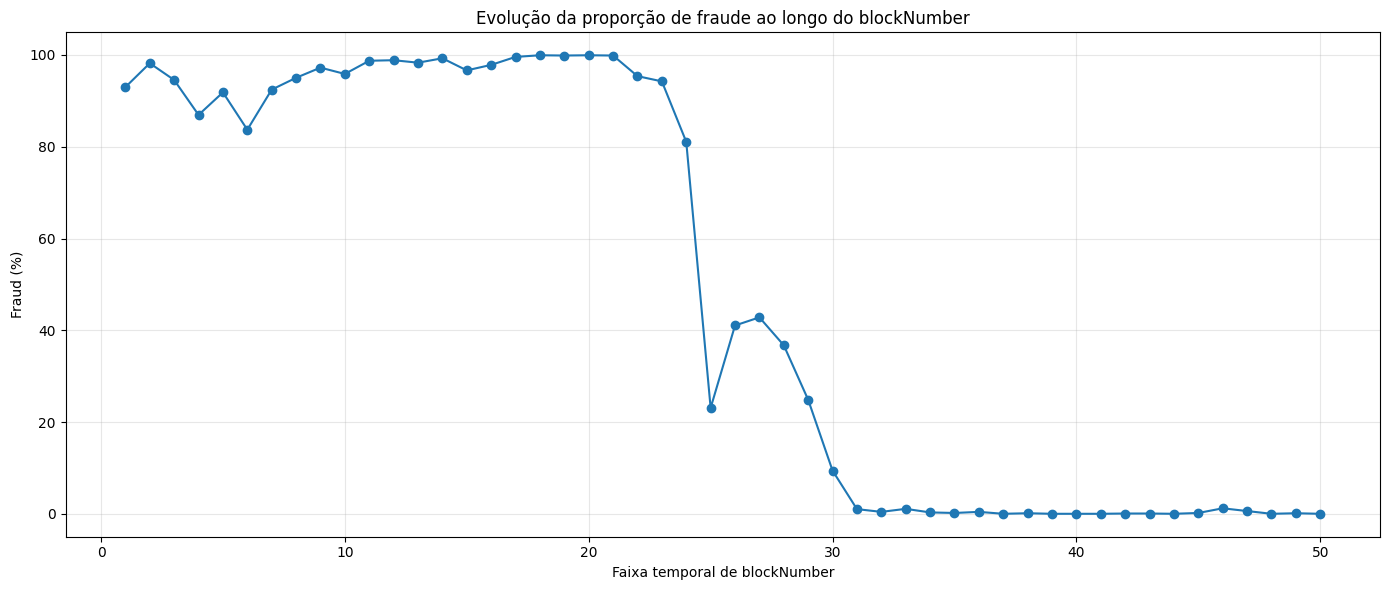

In [50]:
plt.figure(figsize=(14, 6))

plt.plot(
    range(1, len(fraude_temporal) + 1),
    fraude_temporal["percentual_fraude"],
    marker="o"
)

plt.xlabel("Faixa temporal de blockNumber")
plt.ylabel("Fraud (%)")
plt.title("Evolução da proporção de fraude ao longo do blockNumber")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Análise temporal detalhada da variável Fraud

Para aprofundar a investigação da dependência temporal observada
anteriormente, o dataset foi dividido em 50 faixas de `blockNumber`, com
quantidades aproximadamente iguais de registros em cada faixa.

A análise confirmou uma mudança acentuada na proporção de registros
fraudulentos ao longo dos blocos.

Nas primeiras faixas temporais, a proporção de fraude permaneceu
predominantemente entre aproximadamente 85% e 100%. A partir de
aproximadamente 9,5 milhões de blocos, observou-se uma redução
progressiva da proporção de fraude, chegando a valores próximos de 0%
nas faixas posteriores a aproximadamente 14,6 milhões de blocos.

Em diversas faixas posteriores foram observados zero registros
fraudulentos.

Esse comportamento confirma a existência de uma forte mudança de
distribuição temporal no dataset ETFD e reforça a necessidade de tratar
`blockNumber` e outras variáveis relacionadas ao tempo com cautela
durante a construção dos experimentos de aprendizado de máquina.

## Divisão estratificada para os experimentos

Devido à forte mudança de distribuição temporal identificada no dataset,
a divisão temporal não será utilizada como única estratégia de avaliação.

Para a comparação principal entre os modelos, será realizada uma
divisão estratificada dos dados, preservando aproximadamente a mesma
proporção das classes `Fraud` nos conjuntos de treinamento e teste.

Será utilizado 80% dos dados para treinamento e 20% para teste.

A divisão estratificada será utilizada para permitir uma comparação
controlada entre os diferentes modelos e conjuntos de features.

A análise temporal será mantida separadamente como avaliação
complementar da capacidade de generalização para períodos posteriores.

In [51]:
from sklearn.model_selection import train_test_split

# Features e variável-alvo
X = df_etfd_sem_duplicatas.drop(columns=["Fraud"])
y = df_etfd_sem_duplicatas["Fraud"]

# Divisão estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Treinamento:", X_train.shape)
print("Teste:", X_test.shape)

print("\nDistribuição no treinamento:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribuição no teste:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True) * 100)

Treinamento: (66776, 14)
Teste: (16694, 14)

Distribuição no treinamento:
Fraud
0    33760
1    33016
Name: count, dtype: int64
Fraud
0    50.557086
1    49.442914
Name: proportion, dtype: float64

Distribuição no teste:
Fraud
0    8440
1    8254
Name: count, dtype: int64
Fraud
0    50.557086
1    49.442914
Name: proportion, dtype: float64


## Resultado da divisão estratificada

Foi realizada uma divisão estratificada de 80% dos registros para
treinamento e 20% para teste, utilizando `random_state=42`.

O conjunto de treinamento possui 66.776 registros e o conjunto de teste
possui 16.694 registros.

A distribuição das classes foi preservada nos dois conjuntos:

- Treinamento: 50,56% `Fraud = 0` e 49,44% `Fraud = 1`;
- Teste: 50,56% `Fraud = 0` e 49,44% `Fraud = 1`.

A divisão estratificada permite realizar uma comparação controlada entre
os modelos, evitando que diferenças na proporção das classes entre
treinamento e teste influenciem a avaliação.

A divisão temporal analisada anteriormente será mantida como experimento
complementar para avaliar a generalização temporal.

In [52]:
# ==========================================
# Definição dos conjuntos de features
# ==========================================

# Todas as features disponíveis
features_completas = X.columns.tolist()

# Features relacionadas à informação temporal
features_temporais = [
    "blockNumber",
    "confirmations"
]

# Features relacionadas a endereços/transações maliciosas
features_maliciosas = [
    "total_tx_sent_malicious",
    "total_tx_sent_malicious_unique",
    "total_tx_received_malicious_unique"
]

# ------------------------------------------
# Cenário A - Todas as features
# ------------------------------------------

features_A = features_completas


# ------------------------------------------
# Cenário B - Sem blockNumber e confirmations
# ------------------------------------------

features_B = [
    feature
    for feature in features_completas
    if feature not in features_temporais
]


# ------------------------------------------
# Cenário C - Sem features relacionadas
#          a transações maliciosas
# ------------------------------------------

features_C = [
    feature
    for feature in features_completas
    if feature not in features_maliciosas
]


# ------------------------------------------
# Cenário D - Sem os dois grupos
# ------------------------------------------

features_D = [
    feature
    for feature in features_completas
    if feature not in features_temporais
    and feature not in features_maliciosas
]


# Exibir os conjuntos
print("Cenário A - Todas:")
print(features_A)

print("\nCenário B - Sem temporais:")
print(features_B)

print("\nCenário C - Sem features maliciosas:")
print(features_C)

print("\nCenário D - Sem temporais e maliciosas:")
print(features_D)

Cenário A - Todas:
['blockNumber', 'confirmations', 'Month', 'Day', 'Hour', 'mean_value_received', 'variance_value_received', 'total_received', 'time_diff_first_last_received', 'total_tx_sent', 'total_tx_sent_malicious', 'total_tx_sent_unique', 'total_tx_sent_malicious_unique', 'total_tx_received_malicious_unique']

Cenário B - Sem temporais:
['Month', 'Day', 'Hour', 'mean_value_received', 'variance_value_received', 'total_received', 'time_diff_first_last_received', 'total_tx_sent', 'total_tx_sent_malicious', 'total_tx_sent_unique', 'total_tx_sent_malicious_unique', 'total_tx_received_malicious_unique']

Cenário C - Sem features maliciosas:
['blockNumber', 'confirmations', 'Month', 'Day', 'Hour', 'mean_value_received', 'variance_value_received', 'total_received', 'time_diff_first_last_received', 'total_tx_sent', 'total_tx_sent_unique']

Cenário D - Sem temporais e maliciosas:
['Month', 'Day', 'Hour', 'mean_value_received', 'variance_value_received', 'total_received', 'time_diff_first_l

In [53]:
# ==========================================
# Preparação dos dados para cada cenário
# ==========================================

cenarios = {
    "A_Todas": features_A,
    "B_Sem_Temporais": features_B,
    "C_Sem_Maliciosas": features_C,
    "D_Sem_Temporais_Maliciosas": features_D
}

dados_cenarios = {}

for nome, features in cenarios.items():

    dados_cenarios[nome] = {
        "X_train": X_train[features].copy(),
        "X_test": X_test[features].copy(),
        "y_train": y_train.copy(),
        "y_test": y_test.copy()
    }

    print(f"\n{nome}")
    print("Features:", len(features))
    print("Treino:", dados_cenarios[nome]["X_train"].shape)
    print("Teste:", dados_cenarios[nome]["X_test"].shape)


A_Todas
Features: 14
Treino: (66776, 14)
Teste: (16694, 14)

B_Sem_Temporais
Features: 12
Treino: (66776, 12)
Teste: (16694, 12)

C_Sem_Maliciosas
Features: 11
Treino: (66776, 11)
Teste: (16694, 11)

D_Sem_Temporais_Maliciosas
Features: 9
Treino: (66776, 9)
Teste: (16694, 9)


## Feature Engineering das variáveis temporais

As variáveis `Month` e `Hour` representam informações periódicas.
Tratando essas variáveis apenas como números inteiros, valores próximos
ao início e ao final de cada ciclo podem parecer distantes para alguns
modelos.

Por exemplo, as horas 23 e 0 são temporalmente próximas, embora seus
valores numéricos sejam distantes.

Para representar essa característica cíclica, serão criadas
representações trigonométricas utilizando seno e cosseno:

- `Month`: período de 12 meses;
- `Hour`: período de 24 horas.

A variável `Day` será mantida inicialmente em sua forma original, pois
o número de dias varia entre os meses e não será assumido nesta etapa
um ciclo fixo de 31 dias.

As transformações serão posteriormente integradas a pipelines do
Scikit-learn para que o pré-processamento e o treinamento dos modelos
sejam executados de forma organizada.

In [54]:
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer


# Transformação seno
def sin_transformer(periodo):
    return FunctionTransformer(
        lambda x: np.sin(x / periodo * 2 * np.pi),
        feature_names_out="one-to-one"
    )


# Transformação cosseno
def cos_transformer(periodo):
    return FunctionTransformer(
        lambda x: np.cos(x / periodo * 2 * np.pi),
        feature_names_out="one-to-one"
    )


# Função para criar o transformador de acordo
# com as features presentes em cada cenário
def criar_transformador_ciclico(features):

    transformadores = []

    if "Month" in features:
        transformadores.extend([
            ("Month_sin", sin_transformer(12), ["Month"]),
            ("Month_cos", cos_transformer(12), ["Month"])
        ])

    if "Hour" in features:
        transformadores.extend([
            ("Hour_sin", sin_transformer(24), ["Hour"]),
            ("Hour_cos", cos_transformer(24), ["Hour"])
        ])

    return ColumnTransformer(
        transformers=transformadores,
        remainder="passthrough",
        verbose_feature_names_out=True
    )

In [55]:
transformador_A = criar_transformador_ciclico(features_A)

X_train_A_ciclico = transformador_A.fit_transform(
    dados_cenarios["A_Todas"]["X_train"]
)

X_test_A_ciclico = transformador_A.transform(
    dados_cenarios["A_Todas"]["X_test"]
)

print("Antes da Feature Engineering:")
print(dados_cenarios["A_Todas"]["X_train"].shape)

print("\nDepois da Feature Engineering:")
print(X_train_A_ciclico.shape)

print("\nFeatures geradas:")
print(transformador_A.get_feature_names_out())

Antes da Feature Engineering:
(66776, 14)

Depois da Feature Engineering:
(66776, 16)

Features geradas:
['Month_sin__Month' 'Month_cos__Month' 'Hour_sin__Hour' 'Hour_cos__Hour'
 'remainder__blockNumber' 'remainder__confirmations' 'remainder__Day'
 'remainder__mean_value_received' 'remainder__variance_value_received'
 'remainder__total_received' 'remainder__time_diff_first_last_received'
 'remainder__total_tx_sent' 'remainder__total_tx_sent_malicious'
 'remainder__total_tx_sent_unique'
 'remainder__total_tx_sent_malicious_unique'
 'remainder__total_tx_received_malicious_unique']


In [56]:
transformador_A = criar_transformador_ciclico(features_A)

X_train_A_ciclico = transformador_A.fit_transform(
    dados_cenarios["A_Todas"]["X_train"]
)

X_test_A_ciclico = transformador_A.transform(
    dados_cenarios["A_Todas"]["X_test"]
)

print("Antes da Feature Engineering:")
print(dados_cenarios["A_Todas"]["X_train"].shape)

print("\nDepois da Feature Engineering:")
print(X_train_A_ciclico.shape)

print("\nFeatures geradas:")
print(transformador_A.get_feature_names_out())

Antes da Feature Engineering:
(66776, 14)

Depois da Feature Engineering:
(66776, 16)

Features geradas:
['Month_sin__Month' 'Month_cos__Month' 'Hour_sin__Hour' 'Hour_cos__Hour'
 'remainder__blockNumber' 'remainder__confirmations' 'remainder__Day'
 'remainder__mean_value_received' 'remainder__variance_value_received'
 'remainder__total_received' 'remainder__time_diff_first_last_received'
 'remainder__total_tx_sent' 'remainder__total_tx_sent_malicious'
 'remainder__total_tx_sent_unique'
 'remainder__total_tx_sent_malicious_unique'
 'remainder__total_tx_received_malicious_unique']


## Modelo baseline - Regressão Logística

A Regressão Logística será utilizada como modelo baseline para estabelecer
uma referência inicial de desempenho.

O pré-processamento será realizado por meio de um Pipeline do Scikit-learn,
incluindo:

1. transformação cíclica das variáveis `Month` e `Hour`;
2. padronização das features utilizando `StandardScaler`;
3. treinamento da Regressão Logística.

A avaliação será realizada utilizando Accuracy, Precision, Recall, F1-score
e ROC-AUC, além da matriz de confusão.

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Dados do Cenário A
X_train_A = dados_cenarios["A_Todas"]["X_train"]
X_test_A = dados_cenarios["A_Todas"]["X_test"]

# Pipeline completo
pipeline_logistico_A = Pipeline([
    (
        "feature_engineering",
        criar_transformador_ciclico(features_A)
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "modelo",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

# Treinamento
pipeline_logistico_A.fit(X_train_A, y_train)

# Predições
y_pred_A = pipeline_logistico_A.predict(X_test_A)

# Probabilidade de Fraud = 1
y_prob_A = pipeline_logistico_A.predict_proba(X_test_A)[:, 1]

# Métricas
accuracy_A = accuracy_score(y_test, y_pred_A)
precision_A = precision_score(y_test, y_pred_A)
recall_A = recall_score(y_test, y_pred_A)
f1_A = f1_score(y_test, y_pred_A)
auc_A = roc_auc_score(y_test, y_prob_A)

print("=== Regressão Logística - Cenário A ===")

print(f"Accuracy:  {accuracy_A:.4f}")
print(f"Precision: {precision_A:.4f}")
print(f"Recall:    {recall_A:.4f}")
print(f"F1-score:  {f1_A:.4f}")
print(f"ROC-AUC:   {auc_A:.4f}")

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_A))

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_A))

=== Regressão Logística - Cenário A ===
Accuracy:  0.9663
Precision: 0.9686
Recall:    0.9632
F1-score:  0.9659
ROC-AUC:   0.9909

Matriz de confusão:
[[8182  258]
 [ 304 7950]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      8440
           1       0.97      0.96      0.97      8254

    accuracy                           0.97     16694
   macro avg       0.97      0.97      0.97     16694
weighted avg       0.97      0.97      0.97     16694



### Resultado - Regressão Logística no Cenário A

A Regressão Logística utilizando todas as features apresentou os seguintes
resultados no conjunto de teste:

- Accuracy: 96,63%;
- Precision: 96,86%;
- Recall: 96,32%;
- F1-score: 96,59%;
- ROC-AUC: 0,9909.

A matriz de confusão apresentou 7.950 fraudes corretamente identificadas,
304 fraudes classificadas incorretamente como não fraude, 8.182 registros
não fraudulentos classificados corretamente e 258 falsos positivos.

Apesar do elevado desempenho, esses resultados devem ser interpretados
com cautela, pois este cenário contém variáveis que apresentaram forte
associação com a variável-alvo, especialmente `blockNumber`,
`confirmations` e features relacionadas a transações maliciosas.

Por esse motivo, os próximos experimentos avaliarão o mesmo modelo
removendo esses grupos de features.

In [58]:
import pandas as pd

resultados_logistica = []

for nome_cenario, features in cenarios.items():

    X_train_cenario = dados_cenarios[nome_cenario]["X_train"]
    X_test_cenario = dados_cenarios[nome_cenario]["X_test"]

    pipeline = Pipeline([
        (
            "feature_engineering",
            criar_transformador_ciclico(features)
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "modelo",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ])

    # Treinamento
    pipeline.fit(X_train_cenario, y_train)

    # Predições
    y_pred = pipeline.predict(X_test_cenario)
    y_prob = pipeline.predict_proba(X_test_cenario)[:, 1]

    # Armazenar resultados
    resultados_logistica.append({
        "Cenario": nome_cenario,
        "Features": len(features),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })


df_resultados_logistica = pd.DataFrame(resultados_logistica)

df_resultados_logistica

,Cenario,Features,Accuracy,Precision,Recall,F1,ROC_AUC
0,A_Todas,14,0.966335,0.968567,0.963169,0.965861,0.990898
1,B_Sem_Temporais,12,0.800707,0.769913,0.851345,0.808584,0.893728
2,C_Sem_Maliciosas,11,0.946508,0.957375,0.933366,0.945218,0.987674
3,D_Sem_Temporais_Maliciosas,9,0.733018,0.694419,0.821541,0.752650,0.811450


### Comparação dos cenários - Regressão Logística

A comparação entre os diferentes conjuntos de features mostrou uma
redução significativa de desempenho quando `blockNumber` e
`confirmations` foram removidos.

O cenário com todas as features apresentou ROC-AUC de 0,9909 e
F1-score de 0,9659.

Ao remover `blockNumber` e `confirmations`, o ROC-AUC caiu para 0,8937
e o F1-score para 0,8086, indicando forte contribuição dessas variáveis
para a classificação.

A remoção apenas das features relacionadas a transações maliciosas
produziu uma redução menor, com ROC-AUC de 0,9877 e F1-score de 0,9452.

Quando os dois grupos foram removidos, o desempenho apresentou a maior
redução, com ROC-AUC de 0,8115 e F1-score de 0,7527.

Esses resultados indicam que `blockNumber` e `confirmations` exercem
forte influência sobre o desempenho do modelo. Entretanto, considerando
a dependência temporal identificada anteriormente no dataset, o elevado
desempenho obtido com essas variáveis deve ser interpretado com cautela.

A análise não comprova, isoladamente, a existência de data leakage, mas
demonstra que uma parcela relevante da capacidade discriminativa do
modelo está associada a essas variáveis.

## Random Forest

O Random Forest será utilizado como segundo algoritmo supervisionado
para comparação com a Regressão Logística.

Por ser baseado em árvores de decisão, o modelo é capaz de capturar
relações não lineares entre as features e a variável-alvo.

Serão mantidos o mesmo conjunto de treinamento e teste e os mesmos
cenários de features utilizados anteriormente, permitindo uma comparação
direta entre os algoritmos.

In [59]:
from sklearn.ensemble import RandomForestClassifier

resultados_rf = []

for nome_cenario, features in cenarios.items():

    X_train_cenario = dados_cenarios[
        nome_cenario.replace(
            "B_Sem_Block_Confirmations",
            "B_Sem_Temporais"
        ).replace(
            "D_Sem_Block_Confirmations_Maliciosas",
            "D_Sem_Temporais_Maliciosas"
        )
    ]["X_train"]

    X_test_cenario = dados_cenarios[
        nome_cenario.replace(
            "B_Sem_Block_Confirmations",
            "B_Sem_Temporais"
        ).replace(
            "D_Sem_Block_Confirmations_Maliciosas",
            "D_Sem_Temporais_Maliciosas"
        )
    ]["X_test"]

    pipeline_rf = Pipeline([
        (
            "feature_engineering",
            criar_transformador_ciclico(features)
        ),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ])

    pipeline_rf.fit(X_train_cenario, y_train)

    y_pred = pipeline_rf.predict(X_test_cenario)
    y_prob = pipeline_rf.predict_proba(X_test_cenario)[:, 1]

    resultados_rf.append({
        "Cenario": nome_cenario,
        "Features": len(features),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })

df_resultados_rf = pd.DataFrame(resultados_rf)

df_resultados_rf

,Cenario,Features,Accuracy,Precision,Recall,F1,ROC_AUC
0,A_Todas,14,0.997963,0.997097,0.998788,0.997942,0.999910
1,B_Sem_Temporais,12,0.990835,0.988660,0.992852,0.990751,0.998729
2,C_Sem_Maliciosas,11,0.995447,0.993960,0.996850,0.995403,0.999667
3,D_Sem_Temporais_Maliciosas,9,0.931412,0.921599,0.941362,0.931375,0.976843


### Comparação dos cenários - Random Forest

O Random Forest apresentou desempenho superior à Regressão Logística
em todos os cenários avaliados.

No cenário contendo todas as features, o modelo alcançou ROC-AUC de
aproximadamente 0,9999 e Accuracy de 99,80%.

Mesmo com a remoção de `blockNumber` e `confirmations`, o desempenho
permaneceu elevado, com Accuracy de aproximadamente 99,08% e ROC-AUC
de 0,9987.

A remoção das features relacionadas a transações maliciosas também
produziu pequena redução, resultando em Accuracy de aproximadamente
99,54%.

No cenário mais restritivo, sem `blockNumber`, `confirmations` e as
features relacionadas a transações maliciosas, o modelo ainda apresentou
Accuracy de aproximadamente 93,14% e ROC-AUC de 0,9768.

Os resultados sugerem que existem relações não lineares entre as demais
features e a variável `Fraud`, que são melhor capturadas pelo Random
Forest do que pela Regressão Logística.

Entretanto, devido ao elevado desempenho observado e às características
de construção do dataset, esses resultados representam inicialmente uma
avaliação dentro da mesma distribuição dos dados e não devem ser
interpretados isoladamente como evidência de generalização para períodos
futuros.

## Importância das features - Random Forest

Após a avaliação do Random Forest, será analisada a importância atribuída
pelo modelo a cada feature.

Essa análise permite identificar quais variáveis mais contribuíram para
as decisões do modelo e verificar se o elevado desempenho está concentrado
em determinadas características do dataset.

Inicialmente será utilizada a importância calculada internamente pelo
Random Forest. Posteriormente, os resultados poderão ser comparados com
Permutation Importance para uma avaliação complementar.

In [60]:
# ==========================================
# Random Forest - Cenário A
# Importância das features
# ==========================================

pipeline_rf_A = Pipeline([
    (
        "feature_engineering",
        criar_transformador_ciclico(features_A)
    ),
    (
        "modelo",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    )
])

# Treinar somente o Cenário A
pipeline_rf_A.fit(
    dados_cenarios["A_Todas"]["X_train"],
    y_train
)

# Nomes das features após o Feature Engineering
nomes_features = (
    pipeline_rf_A
    .named_steps["feature_engineering"]
    .get_feature_names_out()
)

# Importância calculada pelo Random Forest
importancias = (
    pipeline_rf_A
    .named_steps["modelo"]
    .feature_importances_
)

# Criar tabela
df_importancia_rf = pd.DataFrame({
    "Feature": nomes_features,
    "Importancia": importancias
})

# Ordenar da mais importante para a menos importante
df_importancia_rf = (
    df_importancia_rf
    .sort_values("Importancia", ascending=False)
    .reset_index(drop=True)
)

df_importancia_rf

,Feature,Importancia
0,remainder__blockNumber,0.266292
1,remainder__confirmations,0.255290
2,remainder__total_tx_sent_malicious,0.173419
3,remainder__total_tx_sent_malicious_unique,0.074065
4,remainder__total_tx_sent,0.060470
5,remainder__time_diff_first_last_received,0.057191
6,remainder__total_received,0.037989
7,remainder__mean_value_received,0.021263
8,remainder__total_tx_sent_unique,0.019173
9,remainder__variance_value_received,0.018048


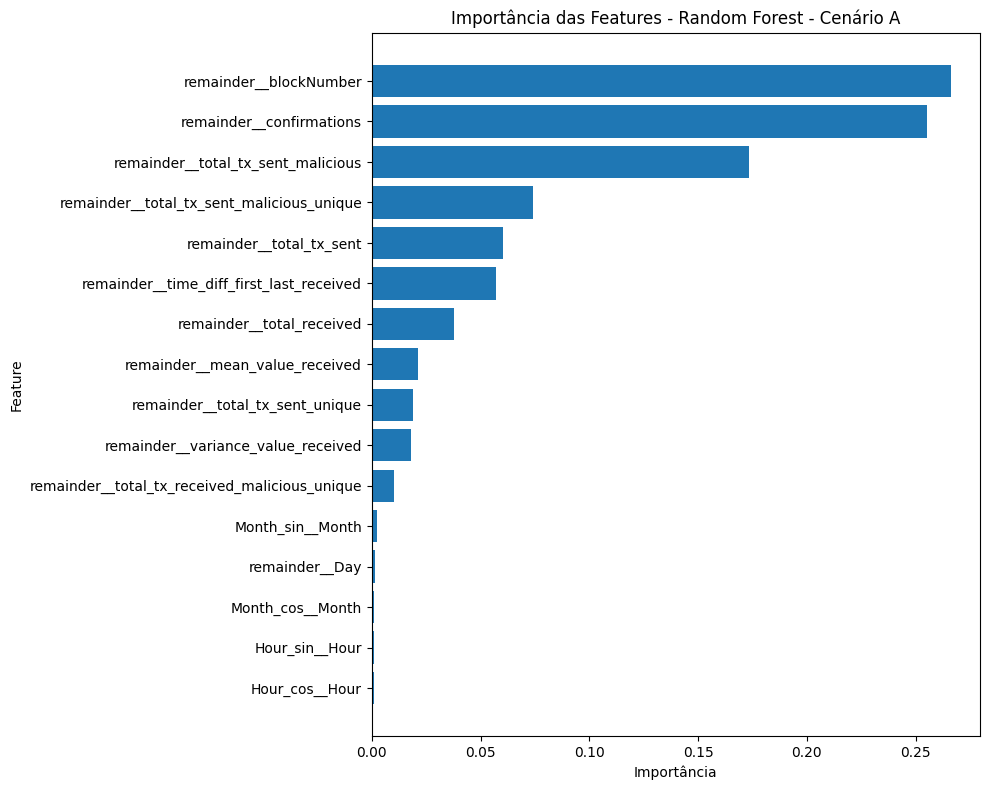

In [61]:
plt.figure(figsize=(10, 8))

plt.barh(
    df_importancia_rf["Feature"],
    df_importancia_rf["Importancia"]
)

plt.xlabel("Importância")
plt.ylabel("Feature")
plt.title("Importância das Features - Random Forest - Cenário A")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Análise da importância das features

A importância interna do Random Forest mostrou forte concentração em
algumas variáveis.

As features `blockNumber` e `confirmations` apresentaram as maiores
importâncias individuais, aproximadamente 26,0% e 25,5%,
respectivamente. Em conjunto, representam aproximadamente 51,6% da
importância atribuída pelo modelo.

As features `total_tx_sent_malicious`,
`total_tx_sent_malicious_unique` e
`total_tx_received_malicious_unique` também apresentaram contribuição
relevante, somando aproximadamente 25,8%.

Esse resultado reforça as observações anteriores sobre a forte influência
das variáveis relacionadas à posição temporal dos blocos e das features
associadas a transações maliciosas.

Entretanto, a importância interna do Random Forest deve ser interpretada
com cautela, especialmente devido à forte correlação existente entre
`blockNumber` e `confirmations`. Por esse motivo, será utilizada também
Permutation Importance como análise complementar.

In [62]:
from sklearn.inspection import permutation_importance

# Permutation Importance usando o conjunto de teste
resultado_permutacao = permutation_importance(
    pipeline_rf_A,
    X_test_A,
    y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

df_permutation = pd.DataFrame({
    "Feature": X_test_A.columns,
    "Importancia_media": resultado_permutacao.importances_mean,
    "Desvio_padrao": resultado_permutacao.importances_std
})

df_permutation = (
    df_permutation
    .sort_values("Importancia_media", ascending=False)
    .reset_index(drop=True)
)

df_permutation

,Feature,Importancia_media,Desvio_padrao
0,blockNumber,0.024740,0.000690
1,total_tx_sent_malicious,0.006169,0.000140
2,total_tx_sent,0.001840,0.000041
3,total_tx_sent_malicious_unique,0.001413,0.000087
4,confirmations,0.000869,0.000080
5,total_tx_sent_unique,0.000601,0.000059
6,time_diff_first_last_received,0.000484,0.000012
7,total_received,0.000271,0.000026
8,variance_value_received,0.000190,0.000011
9,mean_value_received,0.000185,0.000010


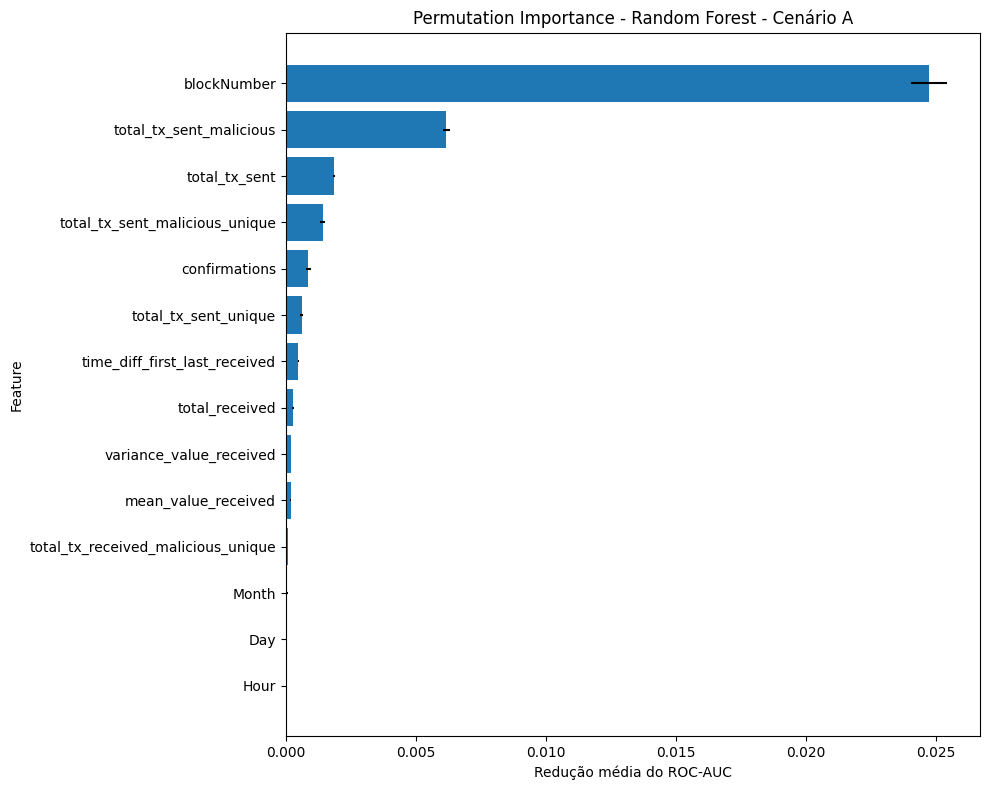

In [63]:
plt.figure(figsize=(10, 8))

plt.barh(
    df_permutation["Feature"],
    df_permutation["Importancia_media"],
    xerr=df_permutation["Desvio_padrao"]
)

plt.xlabel("Redução média do ROC-AUC")
plt.ylabel("Feature")
plt.title("Permutation Importance - Random Forest - Cenário A")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Permutation Importance

A análise por Permutation Importance apresentou `blockNumber` como a
variável com maior impacto individual sobre o desempenho do Random Forest.

Ao embaralhar os valores de `blockNumber`, foi observada uma redução
média de aproximadamente 0,0247 no ROC-AUC.

A feature `total_tx_sent_malicious` apresentou o segundo maior impacto,
com redução média de aproximadamente 0,0062.

Um resultado relevante foi observado para `confirmations`. Embora essa
feature tenha apresentado alta importância na métrica interna do Random
Forest, sua Permutation Importance foi relativamente baixa.

Esse comportamento pode ser explicado pela correlação extremamente alta
entre `blockNumber` e `confirmations`. Como as duas variáveis carregam
informações muito semelhantes, ao embaralhar apenas `confirmations`, o
modelo ainda pode utilizar `blockNumber`.

Esse resultado demonstra a importância de utilizar diferentes métodos
para analisar a relevância das features, especialmente quando existem
variáveis fortemente correlacionadas.

## Feature Selection com SelectKBest

Como etapa complementar à análise de importância das features, será
aplicado o método `SelectKBest` do Scikit-learn.

Será utilizada Mutual Information como critério de seleção, permitindo
avaliar dependências entre cada feature e a variável `Fraud`, inclusive
relações que não sejam necessariamente lineares.

A seleção das features será ajustada exclusivamente sobre os dados de
treinamento para evitar utilização de informações do conjunto de teste
durante o processo de seleção.

In [64]:
from sklearn.metrics import precision_recall_curve, auc

resultados_logistica = []

for nome_cenario, features in cenarios.items():

    X_train_cenario = dados_cenarios[nome_cenario]["X_train"]
    X_test_cenario = dados_cenarios[nome_cenario]["X_test"]

    pipeline = Pipeline([
        (
            "feature_engineering",
            criar_transformador_ciclico(features)
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "modelo",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ])

    # Treinamento
    pipeline.fit(X_train_cenario, y_train)

    # Predições
    y_pred = pipeline.predict(X_test_cenario)
    y_prob = pipeline.predict_proba(X_test_cenario)[:, 1]

    # Curva Precision-Recall
    precision_curve, recall_curve, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    pr_auc = auc(recall_curve, precision_curve)

    resultados_logistica.append({
        "Cenario": nome_cenario,
        "Features": len(features),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "PR_AUC": pr_auc,
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })

df_resultados_logistica = pd.DataFrame(resultados_logistica)

df_resultados_logistica

,Cenario,Features,Accuracy,Precision,Recall,F1,PR_AUC,ROC_AUC
0,A_Todas,14,0.966335,0.968567,0.963169,0.965861,0.986402,0.990898
1,B_Sem_Temporais,12,0.800707,0.769913,0.851345,0.808584,0.892125,0.893728
2,C_Sem_Maliciosas,11,0.946508,0.957375,0.933366,0.945218,0.984415,0.987674
3,D_Sem_Temporais_Maliciosas,9,0.733018,0.694419,0.821541,0.752650,0.806538,0.811450


## Feature Selection com SelectKBest

Como etapa de seleção de atributos, será utilizado o método `SelectKBest`
do Scikit-learn com Mutual Information.

A Mutual Information permite medir a dependência entre cada feature e a
variável-alvo, incluindo relações que não precisam ser exclusivamente
lineares.

A seleção será ajustada somente com o conjunto de treinamento, evitando
que informações do conjunto de teste sejam utilizadas durante a escolha
das features.

Inicialmente serão selecionadas as 8 features com maior pontuação como
experimento exploratório. Posteriormente, diferentes quantidades de
features poderão ser comparadas.

In [65]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from functools import partial

# Feature Engineering somente nos dados de treino
transformador_selecao = criar_transformador_ciclico(features_A)

X_train_transformado = transformador_selecao.fit_transform(
    dados_cenarios["A_Todas"]["X_train"]
)

# Nomes das features depois do Feature Engineering
nomes_features_transformadas = (
    transformador_selecao.get_feature_names_out()
)

# Mutual Information com resultado reproduzível
mutual_info = partial(
    mutual_info_classif,
    random_state=42
)

# Selecionar as 8 melhores features
seletor = SelectKBest(
    score_func=mutual_info,
    k=8
)

seletor.fit(
    X_train_transformado,
    y_train
)

# Criar tabela com todas as pontuações
df_selectkbest = pd.DataFrame({
    "Feature": nomes_features_transformadas,
    "Score_MI": seletor.scores_,
    "Selecionada": seletor.get_support()
})

df_selectkbest = (
    df_selectkbest
    .sort_values("Score_MI", ascending=False)
    .reset_index(drop=True)
)

df_selectkbest

,Feature,Score_MI,Selecionada
0,remainder__confirmations,0.574772,True
1,remainder__blockNumber,0.573329,True
2,remainder__total_tx_sent_malicious,0.385944,True
3,remainder__total_tx_sent_malicious_unique,0.382764,True
4,remainder__mean_value_received,0.337103,True
5,remainder__total_received,0.334465,True
6,remainder__total_tx_sent,0.327617,True
7,remainder__time_diff_first_last_received,0.323033,True
8,remainder__variance_value_received,0.293815,False
9,remainder__total_tx_sent_unique,0.202842,False


### Resultado do SelectKBest com Mutual Information

A aplicação do SelectKBest com Mutual Information selecionou 8 das 16
features disponíveis após a etapa de Feature Engineering.

As variáveis com maiores pontuações foram `confirmations` e `blockNumber`,
seguidas por `total_tx_sent_malicious` e
`total_tx_sent_malicious_unique`.

Também foram selecionadas as variáveis `mean_value_received`,
`total_received`, `total_tx_sent` e
`time_diff_first_last_received`.

As representações cíclicas de `Month` e `Hour`, assim como `Day`,
apresentaram pontuações inferiores e não foram selecionadas neste
experimento.

Os resultados reforçam a forte associação previamente observada de
`blockNumber` e `confirmations` com a variável-alvo. Entretanto, essas
variáveis continuarão sendo analisadas com cautela devido à dependência
temporal identificada no dataset.

In [66]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from functools import partial

mutual_info = partial(
    mutual_info_classif,
    random_state=42
)

pipeline_logistica_selectkbest = Pipeline([
    (
        "feature_engineering",
        criar_transformador_ciclico(features_A)
    ),
    (
        "selectkbest",
        SelectKBest(
            score_func=mutual_info,
            k=8
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "modelo",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

# Treinamento
pipeline_logistica_selectkbest.fit(
    dados_cenarios["A_Todas"]["X_train"],
    y_train
)

# Predições
y_pred_select = pipeline_logistica_selectkbest.predict(
    dados_cenarios["A_Todas"]["X_test"]
)

y_prob_select = pipeline_logistica_selectkbest.predict_proba(
    dados_cenarios["A_Todas"]["X_test"]
)[:, 1]

# PR-AUC
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_prob_select
)

pr_auc_select = auc(
    recall_curve,
    precision_curve
)

print("=== Regressão Logística + SelectKBest (k=8) ===")

print(f"Accuracy:  {accuracy_score(y_test, y_pred_select):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_select):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_select):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_select):.4f}")
print(f"PR-AUC:    {pr_auc_select:.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_select):.4f}")

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_select))

=== Regressão Logística + SelectKBest (k=8) ===
Accuracy:  0.9669
Precision: 0.9699
Recall:    0.9629
F1-score:  0.9664
PR-AUC:    0.9846
ROC-AUC:   0.9883

Matriz de confusão:
[[8193  247]
 [ 306 7948]]


### Avaliação da Regressão Logística após Feature Selection

Após a seleção das 8 features com maior Mutual Information, a Regressão
Logística apresentou desempenho muito próximo ao obtido utilizando todas
as features disponíveis após o Feature Engineering.

O modelo com 8 features apresentou Precision de 0,9699, Recall de 0,9629,
F1-score de 0,9664 e PR-AUC de 0,9846.

Com todas as features, o PR-AUC havia sido 0,9864 e o F1-score 0,9659.

Portanto, a redução do conjunto de atributos provocou apenas uma pequena
alteração no desempenho preditivo, enquanto reduziu de 16 para 8 o número
de features fornecidas ao modelo.

Esse resultado sugere que parte das variáveis pode ser removida sem perda
expressiva de capacidade de classificação.

## Escolha da quantidade de features com validação cruzada

O experimento anterior utilizou inicialmente `k=8` como valor exploratório.

Para definir a quantidade de features de forma mais adequada, diferentes
valores de `k` serão avaliados utilizando somente o conjunto de treinamento.

Será aplicada validação cruzada estratificada com 5 divisões. Em cada
divisão, a etapa de Feature Engineering, a seleção de atributos,
a padronização e o treinamento da Regressão Logística serão ajustados
somente sobre os dados de treinamento daquela divisão.

O PR-AUC médio das validações será utilizado como critério para comparar
as diferentes quantidades de features.

O conjunto de teste não será utilizado para escolher o valor de `k`.

In [67]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Valores de k que serão avaliados
valores_k = [4, 6, 8, 10, 12, 14, 16]

# Validação cruzada estratificada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_k = []

X_train_completo = dados_cenarios["A_Todas"]["X_train"]

for k in valores_k:

    pr_auc_folds = []

    for indice_treino, indice_validacao in cv.split(
        X_train_completo,
        y_train
    ):

        X_treino_fold = X_train_completo.iloc[indice_treino]
        X_validacao_fold = X_train_completo.iloc[indice_validacao]

        y_treino_fold = y_train.iloc[indice_treino]
        y_validacao_fold = y_train.iloc[indice_validacao]

        pipeline_k = Pipeline([
            (
                "feature_engineering",
                criar_transformador_ciclico(features_A)
            ),
            (
                "selectkbest",
                SelectKBest(
                    score_func=mutual_info,
                    k=k
                )
            ),
            (
                "scaler",
                StandardScaler()
            ),
            (
                "modelo",
                LogisticRegression(
                    max_iter=1000,
                    random_state=42
                )
            )
        ])

        # Treinar somente no fold de treinamento
        pipeline_k.fit(
            X_treino_fold,
            y_treino_fold
        )

        # Probabilidade no fold de validação
        y_prob_fold = pipeline_k.predict_proba(
            X_validacao_fold
        )[:, 1]

        # PR-AUC
        precision_fold, recall_fold, _ = precision_recall_curve(
            y_validacao_fold,
            y_prob_fold
        )

        pr_auc_fold = auc(
            recall_fold,
            precision_fold
        )

        pr_auc_folds.append(pr_auc_fold)

    resultados_k.append({
        "k": k,
        "PR_AUC_medio": np.mean(pr_auc_folds),
        "Desvio_padrao": np.std(pr_auc_folds)
    })


df_resultados_k = pd.DataFrame(resultados_k)

df_resultados_k

,k,PR_AUC_medio,Desvio_padrao
0,4,0.967042,0.001198
1,6,0.968505,0.001310
2,8,0.983463,0.001619
3,10,0.982253,0.001017
4,12,0.983715,0.001622
5,14,0.983177,0.001487
6,16,0.983457,0.001305


### Escolha da quantidade de features

Foram avaliados diferentes valores de `k` utilizando validação cruzada
estratificada com 5 divisões sobre o conjunto de treinamento.

O PR-AUC médio foi utilizado como critério de comparação.

O maior PR-AUC médio foi obtido com `k=12`, apresentando valor de
aproximadamente 0,9837.

Os resultados para `k=8`, `k=12`, `k=14` e `k=16` ficaram próximos,
indicando que o desempenho se estabiliza a partir de aproximadamente
8 features.

Seguindo o critério de maior PR-AUC médio definido para este experimento,
`k=12` foi selecionado para a avaliação seguinte no conjunto de teste.

In [68]:
# ==========================================
# Modelo final desta etapa com k = 12
# ==========================================

pipeline_logistica_k12 = Pipeline([
    (
        "feature_engineering",
        criar_transformador_ciclico(features_A)
    ),
    (
        "selectkbest",
        SelectKBest(
            score_func=mutual_info,
            k=12
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "modelo",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

# Treinamento com todo o conjunto de treino
pipeline_logistica_k12.fit(
    dados_cenarios["A_Todas"]["X_train"],
    y_train
)

# Predições no conjunto de teste
y_pred_k12 = pipeline_logistica_k12.predict(
    dados_cenarios["A_Todas"]["X_test"]
)

y_prob_k12 = pipeline_logistica_k12.predict_proba(
    dados_cenarios["A_Todas"]["X_test"]
)[:, 1]

# PR-AUC
precision_curve_k12, recall_curve_k12, _ = precision_recall_curve(
    y_test,
    y_prob_k12
)

pr_auc_k12 = auc(
    recall_curve_k12,
    precision_curve_k12
)

print("=== Regressão Logística + SelectKBest (k=12) ===")

print(f"Accuracy:  {accuracy_score(y_test, y_pred_k12):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_k12):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_k12):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_k12):.4f}")
print(f"PR-AUC:    {pr_auc_k12:.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_k12):.4f}")

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_k12))

=== Regressão Logística + SelectKBest (k=12) ===
Accuracy:  0.9649
Precision: 0.9673
Recall:    0.9615
F1-score:  0.9644
PR-AUC:    0.9854
ROC-AUC:   0.9905

Matriz de confusão:
[[8172  268]
 [ 318 7936]]


In [69]:
# Nomes das features após o Feature Engineering
nomes_features_k12 = (
    pipeline_logistica_k12
    .named_steps["feature_engineering"]
    .get_feature_names_out()
)

# Seletor já treinado dentro do pipeline
seletor_k12 = pipeline_logistica_k12.named_steps["selectkbest"]

# Máscara das features escolhidas
mascara_k12 = seletor_k12.get_support()

# Tabela completa
df_features_k12 = pd.DataFrame({
    "Feature": nomes_features_k12,
    "Score_MI": seletor_k12.scores_,
    "Selecionada": mascara_k12
})

df_features_k12 = (
    df_features_k12
    .sort_values("Score_MI", ascending=False)
    .reset_index(drop=True)
)

df_features_k12

,Feature,Score_MI,Selecionada
0,remainder__confirmations,0.574772,True
1,remainder__blockNumber,0.573329,True
2,remainder__total_tx_sent_malicious,0.385944,True
3,remainder__total_tx_sent_malicious_unique,0.382764,True
4,remainder__mean_value_received,0.337103,True
5,remainder__total_received,0.334465,True
6,remainder__total_tx_sent,0.327617,True
7,remainder__time_diff_first_last_received,0.323033,True
8,remainder__variance_value_received,0.293815,True
9,remainder__total_tx_sent_unique,0.202842,True


### Features selecionadas com k=12

Após a definição de `k=12` por validação cruzada, o SelectKBest com
Mutual Information selecionou 12 das 16 features resultantes da etapa
de Feature Engineering.

Foram selecionadas:

- `confirmations`;
- `blockNumber`;
- `total_tx_sent_malicious`;
- `total_tx_sent_malicious_unique`;
- `mean_value_received`;
- `total_received`;
- `total_tx_sent`;
- `time_diff_first_last_received`;
- `variance_value_received`;
- `total_tx_sent_unique`;
- representação seno de `Month`;
- representação cosseno de `Month`.

As variáveis `total_tx_received_malicious_unique`, `Day` e as
representações cíclicas de `Hour` não foram selecionadas.

A seleção de 12 features manteve desempenho muito próximo ao modelo com
todas as variáveis, apresentando PR-AUC de aproximadamente 0,9854,
contra aproximadamente 0,9864 no modelo sem seleção de atributos.

## Segundo modelo - XGBoost

O XGBoost será utilizado como segundo modelo supervisionado para
comparação com a Regressão Logística.

Por utilizar um conjunto sequencial de árvores de decisão, o algoritmo
é capaz de modelar relações não lineares e interações entre diferentes
features.

Inicialmente, será utilizado o Cenário A, contendo todas as features,
mantendo o mesmo conjunto de treinamento e teste utilizado anteriormente.

As principais métricas avaliadas serão Precision, Recall, F1-Score,
PR-AUC e matriz de confusão. Accuracy e ROC-AUC serão mantidas como
métricas complementares.

In [70]:
from xgboost import XGBClassifier

pipeline_xgb_A = Pipeline([
    (
        "feature_engineering",
        criar_transformador_ciclico(features_A)
    ),
    (
        "modelo",
        XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss"
        )
    )
])

# Treinamento
pipeline_xgb_A.fit(
    dados_cenarios["A_Todas"]["X_train"],
    y_train
)

# Predições
y_pred_xgb = pipeline_xgb_A.predict(
    dados_cenarios["A_Todas"]["X_test"]
)

y_prob_xgb = pipeline_xgb_A.predict_proba(
    dados_cenarios["A_Todas"]["X_test"]
)[:, 1]

# PR-AUC
precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test,
    y_prob_xgb
)

pr_auc_xgb = auc(
    recall_xgb,
    precision_xgb
)

print("=== XGBoost - Cenário A ===")

print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"PR-AUC:    {pr_auc_xgb:.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_xgb):.4f}")

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_xgb))

=== XGBoost - Cenário A ===
Accuracy:  0.9978
Precision: 0.9966
Recall:    0.9989
F1-score:  0.9978
PR-AUC:    0.9999
ROC-AUC:   0.9999

Matriz de confusão:
[[8412   28]
 [   9 8245]]


In [71]:
resultados_xgb = []

for nome_cenario, features in cenarios.items():

    X_train_cenario = dados_cenarios[nome_cenario]["X_train"]
    X_test_cenario = dados_cenarios[nome_cenario]["X_test"]

    pipeline_xgb = Pipeline([
        (
            "feature_engineering",
            criar_transformador_ciclico(features)
        ),
        (
            "modelo",
            XGBClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                random_state=42,
                n_jobs=-1,
                eval_metric="logloss"
            )
        )
    ])

    # Treinamento
    pipeline_xgb.fit(
        X_train_cenario,
        y_train
    )

    # Predições
    y_pred = pipeline_xgb.predict(
        X_test_cenario
    )

    y_prob = pipeline_xgb.predict_proba(
        X_test_cenario
    )[:, 1]

    # PR-AUC
    precision_curve, recall_curve, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    pr_auc = auc(
        recall_curve,
        precision_curve
    )

    resultados_xgb.append({
        "Cenario": nome_cenario,
        "Features": len(features),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "PR_AUC": pr_auc,
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })


df_resultados_xgb = pd.DataFrame(resultados_xgb)

df_resultados_xgb

,Cenario,Features,Accuracy,Precision,Recall,F1,PR_AUC,ROC_AUC
0,A_Todas,14,0.997784,0.996615,0.998910,0.997761,0.999917,0.999926
1,B_Sem_Temporais,12,0.988139,0.985184,0.990913,0.988041,0.999108,0.999170
2,C_Sem_Maliciosas,11,0.995507,0.993722,0.997213,0.995465,0.999273,0.999412
3,D_Sem_Temporais_Maliciosas,9,0.917695,0.886170,0.956385,0.919939,0.973140,0.976668


### Comparação dos cenários - XGBoost

O XGBoost apresentou elevado desempenho nos quatro cenários avaliados.

Com todas as features, o modelo apresentou Recall de aproximadamente
0,9989, F1-score de 0,9978 e PR-AUC de 0,9999.

A remoção de `blockNumber` e `confirmations` provocou redução no
F1-score, que passou para aproximadamente 0,9380. Entretanto, o PR-AUC
permaneceu elevado, em aproximadamente 0,9991.

Essa diferença indica que o modelo mantém elevada capacidade de
ordenação dos registros, embora o threshold padrão de classificação
de 0,5 produza uma relação diferente entre Precision e Recall.

A remoção apenas das features relacionadas a transações maliciosas
causou pequena redução de desempenho, mantendo PR-AUC de aproximadamente
0,9993.

O maior impacto foi observado quando `blockNumber`, `confirmations` e as
features relacionadas a transações maliciosas foram removidas
simultaneamente. Nesse cenário, o F1-score foi aproximadamente 0,9199 e
o PR-AUC aproximadamente 0,9731.

Os resultados indicam que os grupos de features analisados contribuem
para o desempenho, mas também mostram que outras variáveis presentes no
dataset possuem elevado poder discriminativo.

In [72]:
comparacao_modelos = pd.concat([
    df_resultados_logistica.assign(Modelo="Regressão Logística"),
    df_resultados_xgb.assign(Modelo="XGBoost")
])

comparacao_modelos = comparacao_modelos[
    [
        "Modelo",
        "Cenario",
        "Features",
        "Precision",
        "Recall",
        "F1",
        "PR_AUC",
        "Accuracy",
        "ROC_AUC"
    ]
].reset_index(drop=True)

comparacao_modelos

,Modelo,Cenario,Features,Precision,Recall,F1,PR_AUC,Accuracy,ROC_AUC
0,Regressão Logística,A_Todas,14,0.968567,0.963169,0.965861,0.986402,0.966335,0.990898
1,Regressão Logística,B_Sem_Temporais,12,0.769913,0.851345,0.808584,0.892125,0.800707,0.893728
2,Regressão Logística,C_Sem_Maliciosas,11,0.957375,0.933366,0.945218,0.984415,0.946508,0.987674
3,Regressão Logística,D_Sem_Temporais_Maliciosas,9,0.694419,0.821541,0.752650,0.806538,0.733018,0.811450
4,XGBoost,A_Todas,14,0.996615,0.998910,0.997761,0.999917,0.997784,0.999926
5,XGBoost,B_Sem_Temporais,12,0.985184,0.990913,0.988041,0.999108,0.988139,0.999170
6,XGBoost,C_Sem_Maliciosas,11,0.993722,0.997213,0.995465,0.999273,0.995507,0.999412
7,XGBoost,D_Sem_Temporais_Maliciosas,9,0.886170,0.956385,0.919939,0.973140,0.917695,0.976668


## Terceiro modelo - Árvore de Decisão

A Árvore de Decisão será utilizada como terceiro modelo supervisionado
para comparação com a Regressão Logística e o XGBoost.

O algoritmo permite modelar relações não lineares entre as features e a
variável-alvo por meio de divisões sucessivas dos dados.

Serão utilizados os mesmos conjuntos de treinamento e teste e os quatro
cenários de features definidos anteriormente.

As principais métricas de avaliação serão Precision, Recall, F1-Score,
PR-AUC e matriz de confusão. Accuracy e ROC-AUC serão mantidas como
métricas complementares.

In [73]:
from sklearn.tree import DecisionTreeClassifier

resultados_dt = []

for nome_cenario, features in cenarios.items():

    X_train_cenario = dados_cenarios[nome_cenario]["X_train"]
    X_test_cenario = dados_cenarios[nome_cenario]["X_test"]

    pipeline_dt = Pipeline([
        (
            "feature_engineering",
            criar_transformador_ciclico(features)
        ),
        (
            "modelo",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ])

    # Treinamento
    pipeline_dt.fit(
        X_train_cenario,
        y_train
    )

    # Predições
    y_pred = pipeline_dt.predict(
        X_test_cenario
    )

    y_prob = pipeline_dt.predict_proba(
        X_test_cenario
    )[:, 1]

    # PR-AUC
    precision_curve, recall_curve, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    pr_auc = auc(
        recall_curve,
        precision_curve
    )

    resultados_dt.append({
        "Cenario": nome_cenario,
        "Features": len(features),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "PR_AUC": pr_auc,
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })


df_resultados_dt = pd.DataFrame(resultados_dt)

df_resultados_dt

,Cenario,Features,Accuracy,Precision,Recall,F1,PR_AUC,ROC_AUC
0,A_Todas,14,0.996945,0.996009,0.997819,0.996913,0.997453,0.996955
1,B_Sem_Temporais,12,0.986462,0.985017,0.987642,0.986328,0.989414,0.986534
2,C_Sem_Maliciosas,11,0.993710,0.992268,0.995033,0.993648,0.994878,0.993725
3,D_Sem_Temporais_Maliciosas,9,0.921349,0.920718,0.920160,0.920439,0.947597,0.936674


In [74]:
comparacao_3_modelos = pd.concat([
    df_resultados_logistica.assign(Modelo="Regressão Logística"),
    df_resultados_xgb.assign(Modelo="XGBoost"),
    df_resultados_dt.assign(Modelo="Árvore de Decisão")
])

comparacao_3_modelos = comparacao_3_modelos[
    [
        "Modelo",
        "Cenario",
        "Features",
        "Precision",
        "Recall",
        "F1",
        "PR_AUC",
        "Accuracy",
        "ROC_AUC"
    ]
].reset_index(drop=True)

comparacao_3_modelos

,Modelo,Cenario,Features,Precision,Recall,F1,PR_AUC,Accuracy,ROC_AUC
0,Regressão Logística,A_Todas,14,0.968567,0.963169,0.965861,0.986402,0.966335,0.990898
1,Regressão Logística,B_Sem_Temporais,12,0.769913,0.851345,0.808584,0.892125,0.800707,0.893728
2,Regressão Logística,C_Sem_Maliciosas,11,0.957375,0.933366,0.945218,0.984415,0.946508,0.987674
3,Regressão Logística,D_Sem_Temporais_Maliciosas,9,0.694419,0.821541,0.752650,0.806538,0.733018,0.811450
4,XGBoost,A_Todas,14,0.996615,0.998910,0.997761,0.999917,0.997784,0.999926
5,XGBoost,B_Sem_Temporais,12,0.985184,0.990913,0.988041,0.999108,0.988139,0.999170
6,XGBoost,C_Sem_Maliciosas,11,0.993722,0.997213,0.995465,0.999273,0.995507,0.999412
7,XGBoost,D_Sem_Temporais_Maliciosas,9,0.886170,0.956385,0.919939,0.973140,0.917695,0.976668
8,Árvore de Decisão,A_Todas,14,0.996009,0.997819,0.996913,0.997453,0.996945,0.996955
9,Árvore de Decisão,B_Sem_Temporais,12,0.985017,0.987642,0.986328,0.989414,0.986462,0.986534
